# 01a – Data Quality: NYC Citi Bike

**Worked on by:** Andreas Schellekens (file inventory, harmonised schema, Parquet conversion, conversion checks, completeness over time, data quality and cleaning rules, first overview, decisions for the data preparation)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant). All findings and decisions were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup

The Citi Bike data is about 324 million trips in 400 CSV files (about 61 GB). That does not fit in memory, so we do not load it with pandas. Instead we use **DuckDB**, a database that runs inside Python: it runs SQL directly on CSV and Parquet files, streams through them in parallel and only keeps the result in memory. Results of a query come back as a small pandas DataFrame for tables and plots (matplotlib).

The data itself is not in git. Step 00 (`00_download_citibike.py`) downloads and assembles it into `Data/<year>-citibike-tripdata/<month>/`. All paths in this notebook are relative to the `NYCCitiBikeSystemData/` folder.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# One quiet plot style for the whole notebook: light grid, no top/right frame, grey axis text
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
DIVERGING = LinearSegmentedColormap.from_list("decline_growth", ["#c43c3b", "#f0efec", "#1c5cab"])  # red - grey - blue

DATA_DIR = Path("Data")
PARQUET_DIR = DATA_DIR / "parquet" / "trips"  # output of this notebook, git-ignored like all of Data/

con = duckdb.connect()  # in-memory database: the tables stay in the files, only results are kept
con.execute("SET enable_progress_bar = false")  # the progress bar only clutters the notebook output
print("DuckDB", duckdb.__version__)

DuckDB 1.5.6


## 2. Which files we read

Step 00 places the trips of every month as one or more CSV parts (at most 1,000,000 trips each) directly in the month folder. For 2013 and 2018 Citi Bike also ships an **unsplit copy** of every month; step 00 puts that copy in a subfolder `Origineel/`. Reading both would count every trip of those months twice.

We therefore read only the CSVs **directly inside** a month folder (`Data/*/*/*.csv`); the `Origineel/` files are one level deeper and are not matched by this pattern. Section 4.2 proves that the split parts contain exactly the same number of trips as the unsplit copies, so nothing is lost by skipping them.

For every file we also read the first line (the header) to know which of the three CSV formats it uses:

| Format | Period | Header |
|---|---|---|
| `old` | 2013-06 to 2016-09, 2017-04 to 2019-12 | `tripduration,starttime,...` (lowercase) |
| `old_title_case` | 2016-10 to 2017-03 | `Trip Duration,Start Time,...` (same 15 columns in Title Case) |
| `new` | 2020-01 onwards | `ride_id,rideable_type,started_at,...` (13 columns, new system) |

In [2]:
FORMAT_BY_HEADER = {  # start of the header line -> format name
    "tripduration,": "old",
    "Trip Duration,": "old_title_case",
    "ride_id,": "new",
}
MONTH_NAMES = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]


def csv_format(path):
    with open(path, encoding="utf-8") as f:
        header = f.readline()
    for prefix, name in FORMAT_BY_HEADER.items():
        if header.startswith(prefix):
            return name
    raise ValueError(f"unknown header in {path}: {header[:80]}")


rows = []
for path in sorted(DATA_DIR.glob("*-citibike-tripdata/*/*.csv")):
    year, month = int(path.name[:4]), int(path.name[4:6])
    rows.append({
        "file": path.name,
        "path": path.as_posix(),
        "month": f"{year}-{month:02d}",
        "folder_matches": path.parent.name == f"{month}_{MONTH_NAMES[month - 1]}"
                          and path.parent.parent.name == f"{year}-citibike-tripdata",
        "format": csv_format(path),
        "size_mb": path.stat().st_size / 1e6,
    })
files = pd.DataFrame(rows)
skipped = sorted(DATA_DIR.glob("*-citibike-tripdata/*/Origineel/*.csv"))

print(f"{len(files)} CSV files read ({files.size_mb.sum() / 1e3:.1f} GB), "
      f"{files.month.nunique()} months, from {files.month.min()} to {files.month.max()}")
print(f"{len(skipped)} unsplit copies in Origineel/ skipped "
      f"({sum(p.stat().st_size for p in skipped) / 1e9:.1f} GB)")

400 CSV files read (60.9 GB), 159 months, from 2013-06 to 2026-08
19 unsplit copies in Origineel/ skipped (4.4 GB)


The inventory finds 400 CSV files (60.9 GB) for 159 months, June 2013 to August 2026, and skips the 19 unsplit copies in `Origineel/` (4.4 GB).

Before converting anything we check that the inventory is consistent: every file sits in the folder of its own month, no file name occurs twice, all files of a month use the same format, and there is no month missing between the first and the last month.

In [3]:
all_months = pd.period_range(files.month.min(), files.month.max(), freq="M").strftime("%Y-%m")
formats_per_month = files.groupby("month").format.nunique()

assert files.folder_matches.all(), "a file is in the wrong month folder"
assert files.file.is_unique, "a file name occurs twice"
assert formats_per_month.max() == 1, "a month mixes CSV formats"
missing_months = sorted(set(all_months) - set(files.month))
print("Missing months:", missing_months or "none")

summary = (files.assign(year=files.month.str[:4])
           .groupby("year")
           .agg(files=("file", "size"), months=("month", "nunique"), size_gb=("size_mb", "sum"),
                formats=("format", lambda s: ", ".join(sorted(s.unique())))))
summary["size_gb"] = (summary.size_gb / 1e3).round(2)
summary

Missing months: none


,files,months,size_gb,formats
year,,,,
2013,10,7,0.92,old
2014,12,12,1.33,old
2015,16,12,1.62,old
2016,20,12,2.31,"old, old_title_case"
2017,20,12,2.78,"old, old_title_case"
2018,21,12,3.19,old
2019,26,12,3.73,old
2020,27,12,3.61,new
2021,36,12,5.22,new


All checks pass: no month is missing, every file is in the folder of its own month and every month uses a single format. The data grows from 0.9 GB for the 7 months of 2013 to 8.9 GB for 2025. 2016 and 2017 contain both old formats (Title Case from October 2016 to March 2017); from 2020 on everything is in the new format.

## 3. One harmonised schema, stored as Parquet

### 3.1 The column mapping

The three formats describe the same thing (one row = one trip) with different column names and value formats. We map them to one schema. Columns that exist in only one format are kept, and are empty (NULL) for the other format; we do not invent values.

| Harmonised column | `old` / `old_title_case` | `new` | Notes |
|---|---|---|---|
| `ride_id` | - | `ride_id` | unique trip id, only in the new system |
| `started_at`, `ended_at` | `starttime`, `stoptime` | `started_at`, `ended_at` | local New York time (no time zone in the data) |
| `duration_s` | computed | computed | `ended_at - started_at` in seconds, the same definition for every format |
| `tripduration_s` | `tripduration` | - | duration as reported by the old system, kept to compare with `duration_s` |
| `start_station_id`, `end_station_id` | `start station id` | `start_station_id` | text; old ids are whole numbers (`3359`), new ids look like `6890.01` |
| `start_station_name`, `end_station_name` | `start station name` | `start_station_name` | |
| `start_lat`, `start_lng`, `end_lat`, `end_lng` | `start station latitude`, ... | `start_lat`, ... | decimal degrees |
| `user_type` | `usertype`: Subscriber -> `member`, Customer -> `casual` | `member_casual` | annual subscriber vs. day pass / single ride |
| `rideable_type` | - | `rideable_type` | classic or electric bike, only recorded since 2020 |
| `bike_id` | `bikeid` | - | |
| `birth_year`, `gender` | `birth year`, `gender` | - | gender: 0 = unknown, 1 = male, 2 = female |
| `source_format`, `source_month`, `source_file` | added | added | where the row came from, for checks and tracing |

### 3.2 Parsing choices

- **The CSV dialect is fixed** (comma separator, `"` as quote character). DuckDB normally guesses it from a sample of each file; our first run failed on April 2017, because the sample of that file had no quoted value, so DuckDB assumed there were no quotes, and then met `"Industry City, Building 1 Basement"` (a station name with a comma) further down. DuckDB's strict mode stops on such a row instead of silently shifting the columns, which is what we want.
- **Everything is read as text first** (`all_varchar=true`) and then converted with `try_cast`. A value that cannot be converted becomes NULL instead of stopping the whole conversion, and section 4.3 counts how often that happens. Letting DuckDB guess the types per file would give different types in different years.
- **Timestamps** come in four shapes: `2013-10-01 00:01:08` (ISO), `2019-09-25 17:33:01.4710` (ISO with 4 decimals, 2018-2019), `9/1/2014 00:00:25` (US month/day/year, 2014-09 to 2016-09) and `3/1/2015 0:00` (US without seconds, January to June 2015). We try the ISO cast first and then the two US patterns.
- **Station ids** of the old system are sometimes written as `3359.0` (2018-2019), so they are converted to a whole number before being stored as text.
- **Station ids** of the new system look like `6890.01`: a station number, a dot and **two** digits. They are text, not numbers. But in every month since 2020 a small share of the rows (even within one file) writes an id ending in zero with one digit: `5024.1` instead of `5024.10`, as if the value had passed through a number format. A first conversion without a fix showed 114 such one-digit ids; 103 of them also occur in the two-digit form, and for 99 of those the most common station name is identical (the other 4 differ only in spelling, e.g. `St. Nicholas` vs `St Nicholas`). They are the same stations, so a one-digit id gets its zero back (`5024.1` -> `5024.10`). Without this fix one station would count as two in every station analysis.
- **Birth year** is written as `1982`, `1992.0`, `\N` or left empty; the last two become NULL.
- The column names of the CSV header are replaced by our own names (`names=`), which makes `old` and `old_title_case` identical: their 15 columns are in the same order.

In [4]:
OLD_COLUMNS = ["tripduration", "starttime", "stoptime", "start_station_id", "start_station_name", "start_lat",
               "start_lng", "end_station_id", "end_station_name", "end_lat", "end_lng", "bikeid", "usertype",
               "birth_year", "gender"]
NEW_COLUMNS = ["ride_id", "rideable_type", "started_at", "ended_at", "start_station_name", "start_station_id",
               "end_station_name", "end_station_id", "start_lat", "start_lng", "end_lat", "end_lng", "member_casual"]


# Fixed CSV dialect: DuckDB would otherwise guess it from a sample of each file, and a file whose sample has no
# quoted value would be read without quotes (a name like "Industry City, Building 1" would then split in two)
CSV_OPTIONS = "header=true, all_varchar=true, delim=',', quote='\"', escape='\"', filename=true"


def timestamp(column):
    return (f"coalesce(try_cast({column} AS TIMESTAMP), "
            f"try_strptime({column}, ['%m/%d/%Y %H:%M:%S', '%m/%d/%Y %H:%M']))")


def old_station_id(column):
    return f"CAST(try_cast(try_cast({column} AS DOUBLE) AS INTEGER) AS VARCHAR)"


def new_station_id(column):
    return (f"CASE WHEN regexp_matches({column}, '^[0-9]+\\.[0-9]$') THEN {column} || '0' "
            f"ELSE nullif({column}, '') END")


def select_trips(paths, csv_format, month):
    """SQL that reads the CSVs of one month and returns the trips in the harmonised schema."""
    year, month_number = map(int, month.split("-"))
    if csv_format == "new":
        trips = f"""
            SELECT ride_id, {timestamp('started_at')} AS started_at, {timestamp('ended_at')} AS ended_at,
                   NULL::INTEGER AS tripduration_s,
                   {new_station_id('start_station_id')} AS start_station_id, nullif(start_station_name, '') AS start_station_name,
                   try_cast(start_lat AS DOUBLE) AS start_lat, try_cast(start_lng AS DOUBLE) AS start_lng,
                   {new_station_id('end_station_id')} AS end_station_id, nullif(end_station_name, '') AS end_station_name,
                   try_cast(end_lat AS DOUBLE) AS end_lat, try_cast(end_lng AS DOUBLE) AS end_lng,
                   nullif(member_casual, '') AS user_type, nullif(rideable_type, '') AS rideable_type,
                   NULL::INTEGER AS bike_id, NULL::SMALLINT AS birth_year, NULL::TINYINT AS gender, filename
            FROM read_csv({paths}, {CSV_OPTIONS}, names={NEW_COLUMNS})"""
    else:
        trips = f"""
            SELECT NULL::VARCHAR AS ride_id, {timestamp('starttime')} AS started_at, {timestamp('stoptime')} AS ended_at,
                   try_cast(tripduration AS INTEGER) AS tripduration_s,
                   {old_station_id('start_station_id')} AS start_station_id, nullif(start_station_name, '') AS start_station_name,
                   try_cast(start_lat AS DOUBLE) AS start_lat, try_cast(start_lng AS DOUBLE) AS start_lng,
                   {old_station_id('end_station_id')} AS end_station_id, nullif(end_station_name, '') AS end_station_name,
                   try_cast(end_lat AS DOUBLE) AS end_lat, try_cast(end_lng AS DOUBLE) AS end_lng,
                   CASE usertype WHEN 'Subscriber' THEN 'member' WHEN 'Customer' THEN 'casual' END AS user_type,
                   NULL::VARCHAR AS rideable_type, try_cast(bikeid AS INTEGER) AS bike_id,
                   try_cast(try_cast(birth_year AS DOUBLE) AS SMALLINT) AS birth_year,
                   try_cast(gender AS TINYINT) AS gender, filename
            FROM read_csv({paths}, {CSV_OPTIONS}, names={OLD_COLUMNS})"""
    return f"""
        SELECT ride_id, started_at, ended_at,
               date_diff('millisecond', started_at, ended_at) / 1000.0 AS duration_s, tripduration_s,
               start_station_id, start_station_name, start_lat, start_lng,
               end_station_id, end_station_name, end_lat, end_lng,
               user_type, rideable_type, bike_id, birth_year, gender,
               '{csv_format}' AS source_format, DATE '{year}-{month_number:02d}-01' AS source_month,
               parse_filename(filename) AS source_file
        FROM ({trips})"""

### 3.3 Conversion to Parquet

Parquet is a compressed, column-based file format. A query that needs two columns only reads those two columns, and the files are several times smaller than the CSVs. We write **one Parquet file per month** (`Data/parquet/trips/trips_YYYY-MM.parquet`):

- A month that is already converted is skipped, so re-running the notebook takes seconds, and a month added later by step 00 is converted on the next run. To rebuild everything, delete `Data/parquet/`.
- Each file is first written under a temporary name and only renamed when it is complete, so an interrupted run never leaves a half file that would later be skipped as "done".
- All later notebooks read the trips with `read_parquet('Data/parquet/trips/*.parquet')`.

The first run converts all 61 GB in about 4 minutes (221 s on our laptop); the Parquet files take about 10 GB, a sixth of the CSV size.

In [5]:
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
start = time.time()
converted = 0
for month, month_files in files.groupby("month"):
    target = PARQUET_DIR / f"trips_{month}.parquet"
    if target.exists():
        continue
    temporary = target.with_suffix(".parquet.tmp")
    sql = select_trips(month_files.path.tolist(), month_files.format.iloc[0], month)
    con.execute(f"COPY ({sql}) TO '{temporary.as_posix()}' (FORMAT parquet, COMPRESSION zstd)")
    os.replace(temporary, target)
    converted += 1
    print(f"{month}: {len(month_files)} file(s) converted", flush=True)

parquet_files = sorted(PARQUET_DIR.glob("trips_*.parquet"))
print(f"\n{converted} month(s) converted in {time.time() - start:.0f} s; "
      f"{len(parquet_files)} Parquet files, {sum(p.stat().st_size for p in parquet_files) / 1e9:.1f} GB "
      f"(CSV: {files.size_mb.sum() / 1e3:.1f} GB)")


0 month(s) converted in 0 s; 159 Parquet files, 10.4 GB (CSV: 60.9 GB)


From here on the trips are one view called `trips` over all Parquet files. A view is only a stored query: it costs nothing until it is used, and it always reads the files as they are at that moment.

In [6]:
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{PARQUET_DIR.as_posix()}/*.parquet')")
con.sql("DESCRIBE trips").df()[["column_name", "column_type"]]

,column_name,column_type
0,ride_id,VARCHAR
1,started_at,TIMESTAMP
2,ended_at,TIMESTAMP
3,duration_s,DOUBLE
4,tripduration_s,INTEGER
5,start_station_id,VARCHAR
6,start_station_name,VARCHAR
7,start_lat,DOUBLE
8,start_lng,DOUBLE
9,end_station_id,VARCHAR


### 3.4 Trips that are stored twice

Skipping `Origineel/` prevents whole months from being read twice, but a single trip can still occur in two files. To find such trips we need a key that identifies one trip:

- **New system:** `ride_id`, the unique id of every trip.
- **Old system:** there is no trip id, but one bike cannot start two trips in the same second, so `bike_id` + `started_at` identifies a trip.

The search first groups all trips on these keys and keeps only the keys that occur more than once (about a minute), and then fetches the rows of those few keys. Grouping all 323 million complete rows directly took more than 20 minutes.

Our rule: every trip is kept **once**, in the file of the month in which it **started** (that is where Citi Bike normally puts it). When both copies are in the same file, the copy with the earliest end time is kept, so the choice is the same on every run. The removed copies are written to `Data/parquet/removed_duplicates.parquet`, so they remain traceable and section 4.1 can still match every CSV row. Only the affected month files are rewritten, and on a re-run nothing is found any more and nothing changes.

In [7]:
REMOVED_PATH = DATA_DIR / "parquet" / "removed_duplicates.parquet"


def find_duplicated_keys():
    """Table duplicated_keys: every ride_id, and every bike_id + started_at (old system), that occurs more than once."""
    con.execute("""
        CREATE OR REPLACE TABLE duplicated_keys AS
        SELECT ride_id, NULL::INTEGER AS bike_id, NULL::TIMESTAMP AS started_at FROM trips
        WHERE ride_id IS NOT NULL GROUP BY ride_id HAVING count(*) > 1
        UNION ALL
        SELECT NULL, bike_id, started_at FROM trips
        WHERE ride_id IS NULL AND bike_id IS NOT NULL GROUP BY bike_id, started_at HAVING count(*) > 1
    """)
    return con.sql("SELECT count(*) FROM duplicated_keys").fetchone()[0]


def trip_key(table=""):
    """SQL expression for the key of a trip as one text value: ride_id, or bike_id + start time."""
    prefix = f"{table}." if table else ""
    return (f"coalesce({prefix}ride_id, "
            f"CAST({prefix}bike_id AS VARCHAR) || ' ' || CAST({prefix}started_at AS VARCHAR))")


start = time.time()
print(f"Trips stored more than once: {find_duplicated_keys()} (searched in {time.time() - start:.0f} s)")
con.execute(f"""
    CREATE OR REPLACE TABLE duplicate_copies AS
    WITH copies AS (
        SELECT t.* FROM trips AS t SEMI JOIN duplicated_keys AS k ON t.ride_id = k.ride_id
        UNION ALL
        SELECT t.* FROM trips AS t SEMI JOIN duplicated_keys AS k
            ON t.bike_id = k.bike_id AND t.started_at = k.started_at
    )
    SELECT *, {trip_key()} AS trip_key,
           row_number() OVER (PARTITION BY {trip_key()}
                              ORDER BY date_trunc('month', started_at) = source_month DESC,
                                       source_file, ended_at, end_station_id) = 1 AS keep
    FROM copies
""")
con.sql("""
    SELECT source_format, source_month, source_file, count(*) FILTER (WHERE keep) AS copies_kept,
           count(*) FILTER (WHERE NOT keep) AS copies_removed,
           min(started_at) AS first_start, max(started_at) AS last_start
    FROM duplicate_copies GROUP BY ALL ORDER BY source_file
""").df()

Trips stored more than once: 0 (searched in 103 s)


,source_format,source_month,source_file,copies_kept,copies_removed,first_start,last_start


The first run of this notebook found **531** trips stored twice (on later runs the table above is empty, because they have been removed):

- **512 trips of the new system** that started on 30 April 2026 and ended on 1 May 2026. They are in the April files and again in the May files (Citi Bike apparently exported May by end time instead of start time). The two copies have the same `ride_id`, times and stations; in a few the coordinates differ in the 12th decimal or the station id was written as `5024.1` vs `5024.10` (fixed in 3.2). The April copies are kept.
- **1 trip of the old system** that started at exactly 2013-07-01 00:00:00 and is in both the June and the July 2013 file (the end station was renamed between the two files: `1 Ave & E 15 St` vs `E 16 St`). The July copy is kept.
- **18 pairs inside one old-system file** (June and September 2013, May and September 2014, January and February 2015): same bike, same start second, same rider (birth year and gender), mostly the same stations and an end time a few seconds apart, so the same rental was logged twice. In 5 pairs the end differs (e.g. one copy ends after 15 minutes, the other the next morning at another station), so one of the two records is simply wrong; we cannot tell which and keep the one with the earliest end. With 18 of 92 million old-system trips this has no effect on any analysis.

For each month with a copy to remove, the Parquet file is rewritten without the copies of the duplicated trips (anti join on the key) and with the one copy we keep added back. The removed copies are appended to the log file.

In [8]:
to_remove = con.sql("SELECT DISTINCT source_month FROM duplicate_copies WHERE NOT keep ORDER BY 1").fetchall()
for (month,) in to_remove:
    target = PARQUET_DIR / f"trips_{month:%Y-%m}.parquet"
    temporary = target.with_suffix(".parquet.tmp")
    con.execute(f"""
        COPY (
            SELECT t.* FROM read_parquet('{target.as_posix()}') AS t
            ANTI JOIN (SELECT trip_key FROM duplicate_copies WHERE source_month = DATE '{month}') AS d
                ON {trip_key('t')} = d.trip_key
            UNION ALL
            SELECT * EXCLUDE (trip_key, keep) FROM duplicate_copies WHERE keep AND source_month = DATE '{month}'
        ) TO '{temporary.as_posix()}' (FORMAT parquet, COMPRESSION zstd)""")
    os.replace(temporary, target)
    print(f"{month:%Y-%m}: rewritten without its duplicate copies")

if to_remove:
    removed = "SELECT * EXCLUDE (trip_key, keep) FROM duplicate_copies WHERE NOT keep"
    if REMOVED_PATH.exists():  # keep the copies removed by earlier runs as well
        removed = f"SELECT * FROM read_parquet('{REMOVED_PATH.as_posix()}') UNION {removed}"
    temporary = REMOVED_PATH.with_suffix(".parquet.tmp")
    con.execute(f"COPY ({removed}) TO '{temporary.as_posix()}' (FORMAT parquet)")
    os.replace(temporary, REMOVED_PATH)

removed_count = con.sql(f"SELECT count(*) FROM '{REMOVED_PATH.as_posix()}'").fetchone()[0] if REMOVED_PATH.exists() else 0
print(f"Duplicate copies removed in total (this and earlier runs): {removed_count}")

Duplicate copies removed in total (this and earlier runs): 531


## 4. Checking the conversion

The conversion is only useful if every trip of the CSV files arrives in the Parquet files **exactly once**, with readable values. We check that in four ways.

### 4.1 Every CSV row is accounted for

We count the lines of every CSV file with plain Python (independent of DuckDB) and compare them with the number of rows per source file in the Parquet files plus the duplicate copies removed in 3.4. A file has one header line, so it should hold `lines - 1` trips. We also check how the parts are split: Citi Bike normally cuts a month into parts of exactly 1,000,000 trips, so every part except the last one of a month should hold exactly 1,000,000 trips.

In [9]:
def count_trips(path):
    """Number of data lines in a CSV file (all lines minus the header)."""
    lines, last = 0, b""
    with open(path, "rb") as f:
        while chunk := f.read(1 << 24):
            lines += chunk.count(b"\n")
            last = chunk[-1:]
    return lines - 1 + (last != b"\n")  # a last line without newline still counts


start = time.time()
files["csv_trips"] = [count_trips(p) for p in files.path]
print(f"Lines counted in {time.time() - start:.0f} s")

counts = con.sql("SELECT source_file AS file, count(*) AS parquet_trips FROM trips GROUP BY ALL").df()
if REMOVED_PATH.exists():
    removed_per_file = con.sql(f"SELECT source_file AS file, count(*) AS removed FROM '{REMOVED_PATH.as_posix()}' GROUP BY ALL").df()
    counts = counts.merge(removed_per_file, on="file", how="left")
else:
    counts["removed"] = 0
counts["removed"] = counts.removed.fillna(0).astype(int)
files = files.drop(columns=["parquet_trips", "removed"], errors="ignore").merge(counts, on="file", how="left")

mismatch = files[files.csv_trips != files.parquet_trips + files.removed]
print(f"Trips in the CSV files:                {files.csv_trips.sum():,}")
print(f"Trips in the Parquet files:            {files.parquet_trips.sum():,}")
print(f"Duplicate copies removed (3.4):        {files.removed.sum():,}")
print("Files where CSV != Parquet + removed:", "none" if mismatch.empty else len(mismatch))
mismatch[["file", "csv_trips", "parquet_trips", "removed"]] if not mismatch.empty else None

Lines counted in 127 s
Trips in the CSV files:                323,817,638
Trips in the Parquet files:            323,817,107
Duplicate copies removed (3.4):        531
Files where CSV != Parquet + removed: none


All **323,817,638** data lines of the 400 CSV files are accounted for: 323,817,107 trips are in the Parquet files and 531 duplicate copies were removed in 3.4 (on the first run, before removal, the Parquet files held exactly 323,817,638 rows). No file lost or gained a row, so the conversion, including the quoted station names, reads every line.

In [10]:
files["part_of_month"] = files.groupby("month").cumcount() + 1
files["parts_in_month"] = files.groupby("month").file.transform("size")
not_last = files[files.part_of_month < files.parts_in_month]
irregular = not_last[not_last.csv_trips != 1_000_000]
print(f"{len(not_last)} parts are not the last part of their month; "
      f"{len(irregular)} of them do not hold exactly 1,000,000 trips")
files.loc[files.month.isin(irregular.month), ["file", "csv_trips"]] if not irregular.empty else None

241 parts are not the last part of their month; 3 of them do not hold exactly 1,000,000 trips


,file,csv_trips
374,202604-citibike-tripdata-1.csv,965093
375,202604-citibike-tripdata-2.csv,965093
376,202604-citibike-tripdata-3.csv,965093
377,202604-citibike-tripdata-4.csv,965092


All parts are cut at exactly 1,000,000 trips, except April 2026: that month was published differently (file names `-part1` to `-part4`, which step 00 renames to `-1` to `-4`) and is split into four almost equal parts of 965,093 trips. Their total equals the trips of the month, so this is only a different way of splitting, not missing data.

### 4.2 The split parts hold the same trips as the skipped `Origineel/` copies

For the 19 months that also have an unsplit copy, the sum of the parts must equal the number of trips in the copy. If it does, skipping `Origineel/` loses nothing, and reading it as well would have doubled these months.

In [11]:
originals = pd.DataFrame({"month": [f"{p.name[:4]}-{p.name[4:6]}" for p in skipped],
                          "origineel_trips": [count_trips(p) for p in skipped]})
originals = originals.merge(files.groupby("month").agg(parts=("file", "size"), parts_trips=("csv_trips", "sum")),
                            on="month").sort_values("month", ignore_index=True)
originals["same"] = originals.origineel_trips == originals.parts_trips
print(f"{originals.same.sum()} of {len(originals)} months: the parts hold exactly as many trips as the unsplit copy")
originals

19 of 19 months: the parts hold exactly as many trips as the unsplit copy


,month,origineel_trips,parts,parts_trips,same
0,2013-06,577703,1,577703,True
1,2013-07,843416,1,843416,True
2,2013-08,1001958,2,1001958,True
3,2013-09,1034359,2,1034359,True
4,2013-10,1037712,2,1037712,True
5,2013-11,675774,1,675774,True
6,2013-12,443966,1,443966,True
7,2018-01,718994,1,718994,True
8,2018-02,843114,1,843114,True
9,2018-03,976672,1,976672,True


For all 19 months (June to December 2013 and all of 2018) the parts contain exactly as many trips as the unsplit copy, for example 1,977,177 trips in August 2018. Reading only the parts therefore loses nothing; reading `Origineel/` as well would have added 23,163,227 trips that already exist.

### 4.3 Values that could not be parsed

`try_cast` turns an unreadable value into NULL. To separate "empty in the CSV" from "unreadable", we count the NULLs of the key columns per format. A start or end time that is NULL would mean a timestamp shape we did not anticipate; empty station ids or coordinates can be genuine (electric bikes can be parked outside a station since 2020). Missing values are analysed properly in the next step of the EDA; here we only want to be sure that the conversion did not lose readable values. We also check that no new-system station id with one decimal is left (3.2).

In [12]:
nulls = con.sql("""
    SELECT source_format,
           count(*) AS trips,
           count(*) FILTER (WHERE started_at IS NULL) AS no_start_time,
           count(*) FILTER (WHERE ended_at IS NULL) AS no_end_time,
           count(*) FILTER (WHERE start_station_id IS NULL) AS no_start_station,
           count(*) FILTER (WHERE start_lat IS NULL) AS no_start_lat,
           count(*) FILTER (WHERE user_type IS NULL) AS no_user_type,
           count(*) FILTER (WHERE source_format <> 'new' AND tripduration_s IS NULL) AS no_tripduration,
           count(*) FILTER (WHERE source_format <> 'new' AND bike_id IS NULL) AS no_bike_id,
           count(*) FILTER (WHERE source_format <> 'new' AND birth_year IS NULL) AS no_birth_year,
           count(*) FILTER (WHERE regexp_matches(start_station_id, '^[0-9]+\\.[0-9]$')
                              OR regexp_matches(end_station_id, '^[0-9]+\\.[0-9]$')) AS one_decimal_station_id
    FROM trips GROUP BY ALL ORDER BY source_format
""").df()
nulls

,source_format,trips,no_start_time,no_end_time,no_start_station,no_start_lat,no_user_type,no_tripduration,no_bike_id,no_birth_year,one_decimal_station_id
0,new,231872705,0,0,86483,85836,0,0,0,0,0
1,old,86115408,0,0,2677,0,0,0,0,5814711,0
2,old_title_case,5828994,0,0,0,0,51780,0,0,414763,0


- **Start and end time:** 0 NULLs in all three formats, so every one of the four timestamp shapes was recognised.
- **Duration, bike id:** never missing in the old system.
- **Station:** 86,483 new-system trips (0.04%) have no start station and 85,836 no start coordinates; 2,677 old-system trips have no start station id but do have coordinates. Both are small; the next step of the EDA looks at what they are.
- **User type:** 51,780 trips of October 2016 to March 2017 (0.9% of that format) have an empty user type; the other formats are complete.
- **Birth year:** missing for 5,814,711 old-system trips (6.8%) and 414,763 Title Case trips (7.1%), 96% of them casual riders, for whom it was apparently optional. Birth year and gender only exist until 2019 anyway.
- **Station ids:** no one-decimal id is left after the fix of 3.2.

### 4.4 No trip is stored twice any more

We repeat the key search of 3.4 on the cleaned files: every `ride_id` and every `bike_id` + `started_at` must now occur exactly once.

One more kind of duplicate is possible in theory: the same trip under two **different** `ride_id`s. We checked that once by grouping the new-system trips on all their other columns (times, stations, coordinates, bike type, user type): no such pair exists. That query takes about 8 minutes, so it only runs when `RUN_SLOW_CHECKS` is set to `True`.

In [13]:
RUN_SLOW_CHECKS = False

remaining = find_duplicated_keys()
print(f"Keys that still occur more than once: {remaining}")
assert remaining == 0

if RUN_SLOW_CHECKS:
    same_content = con.sql("""
        SELECT count(*) FROM (
            SELECT 1 FROM trips WHERE source_format = 'new'
            GROUP BY started_at, ended_at, start_station_id, end_station_id, start_lat, start_lng, end_lat, end_lng,
                     rideable_type, user_type
            HAVING count(*) > 1)
    """).fetchone()[0]
    print("Trips with the same content under different ride_ids:", same_content)

Keys that still occur more than once: 0


## 5. The harmonised dataset

Number of trips, months and the range of start times per year and format, as the basis for the rest of the EDA. The year is the year of the **file** (`source_month`), not of the start time.

In [14]:
per_year = con.sql("""
    SELECT year(source_month) AS year, source_format, count(DISTINCT source_month) AS months,
           count(*) AS trips, min(started_at) AS first_start, max(started_at) AS last_start
    FROM trips GROUP BY ALL ORDER BY year, source_format
""").df()
per_year["trips"] = per_year.trips.map("{:,}".format)
per_year

,year,source_format,months,trips,first_start,last_start
0,2013,old,7,"5,614,880",2013-06-01 00:00:01.000,2013-12-31 23:58:16.000
1,2014,old,12,"8,081,210",2014-01-01 00:00:06.000,2014-12-31 23:58:16.000
2,2015,old,12,"9,937,964",2015-01-01 00:01:00.000,2015-12-31 23:58:24.000
3,2016,old,9,"10,262,649",2016-01-01 00:00:41.000,2016-09-30 23:59:51.000
4,2016,old_title_case,3,"3,583,006",2016-10-01 00:00:07.000,2016-12-31 23:59:56.000
5,2017,old,9,"14,118,669",2017-04-01 00:00:58.000,2017-12-31 23:58:56.000
6,2017,old_title_case,3,"2,245,988",2017-01-01 00:00:21.000,2017-03-31 23:59:49.000
7,2018,old,12,"17,548,339",2018-01-01 00:01:50.650,2018-12-31 23:59:51.085
8,2019,old,12,"20,551,697",2019-01-01 00:01:47.401,2019-12-31 23:59:55.296
9,2020,new,12,"19,562,314",2019-01-19 18:24:31.851,2020-12-31 23:56:20.484


The yearly totals grow from about 8 million trips in 2014 to about 45 million in 2024 and 2025; 2013 (7 months) and 2026 (8 months) are incomplete years. One thing stands out for the next step: from 2020 on, every year's files contain a few trips that **started long before** the month of the file, for example a trip from 19 January 2019 in a 2020 file. Such start times are suspicious and are examined in the data-quality checks of the next step; they were kept here because 3.4 only removes trips that exist twice.

Five random trips show what a row of the harmonised data looks like (the seed makes the sample the same on every run).

In [15]:
con.sql("SELECT * FROM trips USING SAMPLE 5 ROWS (reservoir, 42)").df()

,ride_id,started_at,ended_at,duration_s,tripduration_s,start_station_id,start_station_name,start_lat,start_lng,end_station_id,end_station_name,end_lat,end_lng,user_type,rideable_type,bike_id,birth_year,gender,source_format,source_month,source_file
0,None,2013-06-27 21:40:22,2013-06-27 21:53:55,813.0,813,521,8 Ave & W 31 St N,40.750967,-73.994442,450,W 49 St & 8 Ave,40.762272,-73.987882,member,None,17310,1952,1,old,2013-06-01,201306-citibike-tripdata_1.csv
1,None,2013-06-27 23:50:30,2013-06-28 00:02:22,712.0,712,293,Lafayette St & E 8 St,40.730207,-73.991026,280,E 10 St & 5 Ave,40.733320,-73.995101,casual,None,17839,<NA>,0,old,2013-06-01,201306-citibike-tripdata_1.csv
2,None,2013-06-28 15:14:23,2013-06-28 15:21:48,445.0,445,250,Lafayette St & Jersey St N,40.724561,-73.995653,492,W 33 St & 7 Ave,40.750200,-73.990931,member,None,18130,1962,1,old,2013-06-01,201306-citibike-tripdata_1.csv
3,None,2013-06-28 16:37:38,2013-06-28 16:42:19,281.0,281,427,Bus Slip & State St,40.701907,-74.013942,363,West Thames St,40.708347,-74.017134,member,None,18096,1954,1,old,2013-06-01,201306-citibike-tripdata_1.csv
4,None,2013-06-28 17:12:11,2013-06-28 17:24:25,734.0,734,521,8 Ave & W 31 St N,40.750967,-73.994442,468,Broadway & W 56 St,40.765265,-73.981923,member,None,16730,1988,2,old,2013-06-01,201306-citibike-tripdata_1.csv


## 6. Completeness over time

Step 1 showed that no file and no month is missing. That does not yet mean every **period** is complete: a month can exist but miss days, or trips can sit in the file of another month. In this section we look at the number of trips over time and ask three questions:

1. To which month does a trip belong: the month of its file, or the month in which it started?
2. Is every month plausible compared with the same month in other years?
3. Are there days without trips, and can we explain them?

### 6.1 Which month does a trip belong to?

Every trip has a file month (`source_month`) and a start month. Below we count, per format, the trips that **started before** the month of their file, the trips that **ended after** it, and the trips that started after it.

In [16]:
assignment = con.sql("""
    SELECT source_format,
           count(*) AS trips,
           count(*) FILTER (WHERE started_at < source_month) AS started_before_file_month,
           count(*) FILTER (WHERE started_at < source_month - INTERVAL 1 DAY) AS started_more_than_a_day_before,
           count(*) FILTER (WHERE started_at >= source_month + INTERVAL 1 MONTH) AS started_after_file_month,
           count(*) FILTER (WHERE ended_at >= source_month + INTERVAL 1 MONTH) AS ended_after_file_month
    FROM trips GROUP BY ALL ORDER BY source_format
""").df()
assignment

,source_format,trips,started_before_file_month,started_more_than_a_day_before,started_after_file_month,ended_after_file_month
0,new,231872705,45871,7072,0,512
1,old,86115408,0,0,0,12256
2,old_title_case,5828994,0,0,0,445


The two systems file their trips differently:

- **Old system (2013-2019):** a trip is in the file of the month in which it **started**. 12,701 old trips end in the next month, but none started before or after the month of its file.
- **New system (2020 onwards):** a trip is in the file of the month in which it **ended**. 45,871 new trips started in an earlier month; 38,799 of them simply started on the evening before the 1st and ended after midnight. The other 7,072 started more than a day earlier and lasted weeks to more than a year (median about 32 days). These are most likely bikes that were not returned on time; trip durations are checked in the next step.
- The 512 new trips that "ended after the file month" are the April 2026 copies kept in 3.4: April 2026 is the one new-system month that was published by start month, which is exactly why its last-day trips were also in the May file.

**Consequence for the whole analysis:** trips are always counted by their **start time** (`started_at`), never by `source_month`. One side effect: trips that start on 31 August 2026 and end in September are in the September file, which is not published yet, so the very last evening of the data is slightly incomplete (a few hundred trips, judged by the 38,799 midnight-crossing trips over 79 months).

### 6.2 Trips per month

We first build one small table with the number of trips per day and per format (4,830 days with trips, a few seconds for DuckDB), and derive the monthly counts from it with pandas. Everything that follows uses these aggregates, not the 323 million rows.

In [17]:
daily_by_format = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, source_format, count(*) AS trips
    FROM trips GROUP BY ALL ORDER BY day
""").df()
daily_by_format["day"] = pd.to_datetime(daily_by_format.day)

all_days = pd.date_range(daily_by_format.day.min(), "2026-08-31", freq="D")
daily = daily_by_format.groupby("day").trips.sum().reindex(all_days, fill_value=0)  # a day without trips counts 0
monthly = daily.resample("MS").sum()
monthly_by_format = (daily_by_format.assign(month=daily_by_format.day.dt.to_period("M").dt.to_timestamp())
                     .groupby(["month", "source_format"]).trips.sum().unstack())

print(f"{len(all_days)} days from {all_days[0]:%Y-%m-%d} to {all_days[-1]:%Y-%m-%d}, "
      f"{(daily > 0).sum()} with trips; {len(monthly)} months")
monthly.groupby(monthly.index.year).sum().rename("trips").to_frame().T

4840 days from 2013-06-01 to 2026-08-31, 4830 with trips; 159 months


,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
trips,5614880,8081210,9937964,13845655,16364657,17548339,20552228,19562792,27129753,29838442,35107120,44303006,45771161,30159900


The monthly totals as one bar per month over the 159 months. The bars are coloured by the CSV format of their files, so a jump at a format change would be visible immediately. (A line would be drawn straight across the six Title Case months for the lowercase format, which suggests data that is not there; bars avoid that.) A few trips of the new system start long before 2020 (6.1); they are left out of the plot because a handful of trips per month is invisible on this scale.

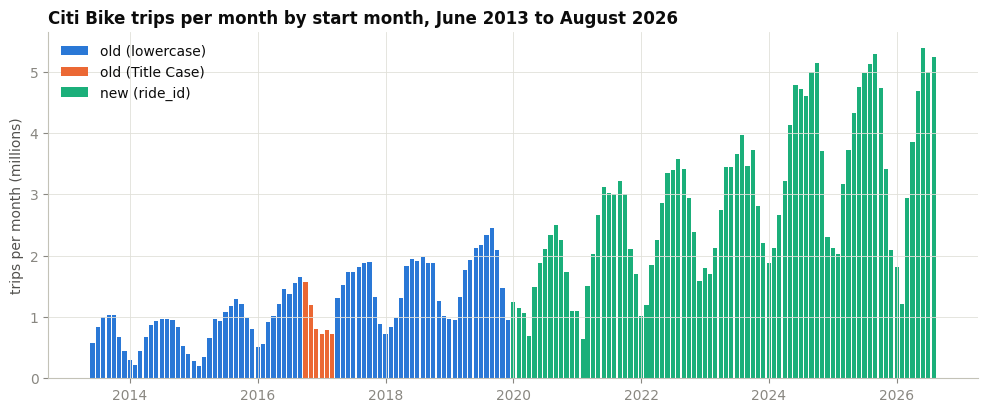

In [18]:
FORMAT_COLOURS = {"old": "#2a78d6", "old_title_case": "#eb6834", "new": "#1baf7a"}
FORMAT_LABELS = {"old": "old (lowercase)", "old_title_case": "old (Title Case)", "new": "new (ride_id)"}

fig, ax = plt.subplots(figsize=(12, 4.5))
for csv_format, colour in FORMAT_COLOURS.items():
    series = monthly_by_format[csv_format].dropna()
    series = series[series > 1000] / 1e6  # drops the handful of new-system trips that started before 2020
    ax.bar(series.index, series.values, width=24, color=colour, label=FORMAT_LABELS[csv_format])
ax.set_ylabel("trips per month (millions)")
ax.set_title("Citi Bike trips per month by start month, June 2013 to August 2026", loc="left")
ax.set_ylim(0, None)
ax.legend(loc="upper left", frameon=False)
plt.show()

- **No gap:** every month from June 2013 to August 2026 has trips, and the bars show no jump at the two format changes (October 2016, January 2020), so the harmonisation did not shift the counts.
- **Growth:** from 8.1 million trips in 2014 to 45.8 million in 2025, more than five times as many. January to August 2026 (30.2 million) is level with the same months of 2025 (30.2 million).
- **Seasons:** every year has a winter low and a summer/autumn high; in 2025 the busiest month (September, 5.3 million) had 2.6 times as many trips as the quietest (February, 2.0 million).
- **Dips:** April 2020 (COVID-19 lockdown) and February 2026 stand out; the next cell quantifies them.

### 6.3 Each month compared with the same month a year earlier

Because of the strong seasons, a month can only be judged against the same month in another year. The heatmap shows the change in trips compared with the same month one year earlier: blue is growth, red is decline, grey is no change. A month with missing days or a broken file would show up as an isolated red cell.

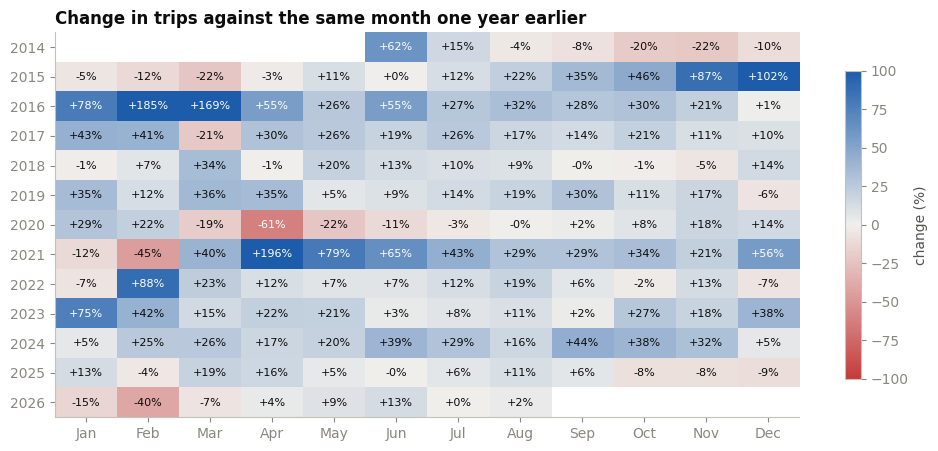

Largest declines:
2020-04-01   -61.2
2021-02-01   -44.6
2026-02-01   -40.0
2020-05-01   -22.5
2015-03-01   -22.2


In [19]:
yoy = (monthly / monthly.shift(12) - 1) * 100  # percent change against the same month a year earlier
yoy_table = yoy.dropna().to_frame("change").assign(year=lambda d: d.index.year, month=lambda d: d.index.month)
yoy_table = yoy_table.pivot(index="year", columns="month", values="change")

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(yoy_table.values, cmap=DIVERGING, vmin=-100, vmax=100, aspect="auto")
ax.set_xticks(range(12), [name[:3] for name in MONTH_NAMES])
ax.set_yticks(range(len(yoy_table)), yoy_table.index)
for (row, col), value in np.ndenumerate(yoy_table.values):
    if not np.isnan(value):
        ax.text(col, row, f"{value:+.0f}%", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 55 else INK_PRIMARY)
ax.grid(False)
ax.set_title("Change in trips against the same month one year earlier", loc="left")
fig.colorbar(image, ax=ax, label="change (%)", shrink=0.8)
plt.show()

print("Largest declines:")
print(yoy.dropna().sort_values().head(5).round(1).to_string())

Almost all cells are blue: the system grew in nearly every month. Only three months fell by more than a quarter, and each has an outside explanation:

- **April 2020: -61%** (684,573 trips against 1,766,106 in April 2019). New York's COVID-19 lockdown; May 2020 is still -22%, and from June 2020 the numbers are back above 2019.
- **February 2021: -45%**. This month contains a day without trips and a day with only 241 trips (6.4).
- **February 2026: -40%** (1,219,706 trips against 2,031,394). The daily numbers show very few trips from 25 January 2026 onwards (3,053 that day, around 20,000 a day in the following week against 60,000 to 97,000 a day in the week before) and one day without trips (6.4).

The daily weather data planned for the next notebook should explain the two February dips.

There is no isolated red month without such an explanation, so we find no sign of missing data inside the months. The dark blue cells (e.g. +185% in February 2016, +196% in April 2021) are growth after a weak or disrupted month a year earlier, not double counting: step 1 showed that every trip is stored once.

### 6.4 Days without trips

The daily totals over the whole period. Days with **no trip at all** are marked; a day without any trip in a system with tens of thousands of trips per day means the system was closed or the data of that day is missing.

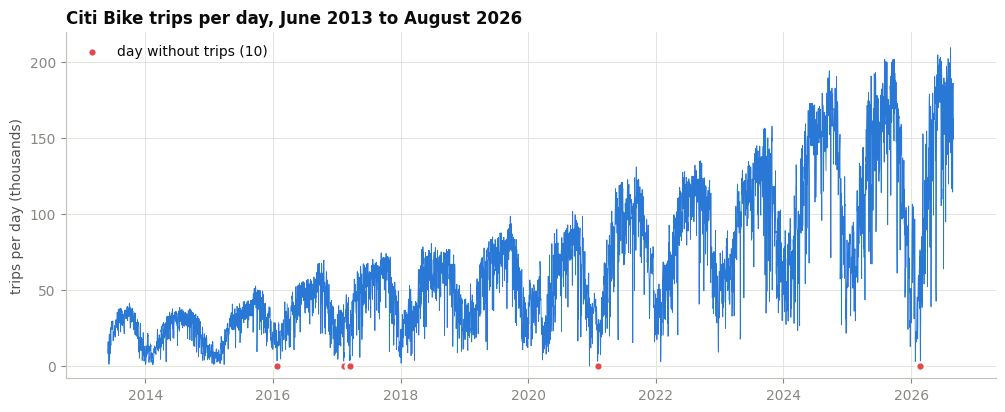

In [20]:
zero_days = daily[daily == 0]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.index, daily.values / 1e3, color=FORMAT_COLOURS["old"], linewidth=0.6)
ax.scatter(zero_days.index, np.zeros(len(zero_days)), color="#e34948", s=36, zorder=3,
           edgecolor="white", linewidth=1.5, label=f"day without trips ({len(zero_days)})")
ax.set_ylabel("trips per day (thousands)")
ax.set_title("Citi Bike trips per day, June 2013 to August 2026", loc="left")
ax.set_ylim(-8, None)
ax.legend(loc="upper left", frameon=False)
plt.show()

The daily line shows the same growth and seasons, with a lot of day-to-day variation (weekdays against weekends, rain). The days without trips are all in winter. To see whether they are isolated data gaps or part of a disruption, we list each one with the trips on the day before and after, and compare with the median of the surrounding four weeks.

In [21]:
typical = daily.rolling(29, center=True, min_periods=10).median()  # typical day in the surrounding 4 weeks
zero_table = pd.DataFrame({
    "weekday": zero_days.index.day_name(),
    "day_before": [daily.get(d - pd.Timedelta(days=1)) for d in zero_days.index],
    "day_after": [daily.get(d + pd.Timedelta(days=1)) for d in zero_days.index],
    "typical_day": typical[zero_days.index].round(),
}, index=zero_days.index.strftime("%Y-%m-%d"))
zero_table

,weekday,day_before,day_after,typical_day
2016-01-23,Saturday,20950,0,16933.0
2016-01-24,Sunday,0,0,16933.0
2016-01-25,Monday,0,0,17281.0
2016-01-26,Tuesday,0,6761,17281.0
2017-02-09,Thursday,40428,1997,29632.0
2017-03-14,Tuesday,27417,0,26927.0
2017-03-15,Wednesday,0,0,26927.0
2017-03-16,Thursday,0,7098,26927.0
2021-02-02,Tuesday,241,6392,25409.0
2026-02-23,Monday,19037,13135,54992.0


The 10 days without trips form 5 episodes: 23-26 January 2016, 9 February 2017, 14-16 March 2017, 2 February 2021 and 23 February 2026. Two more days are almost empty: 1 February 2021 (241 trips, the day before the zero day) and 17 December 2020 (180 trips). The day **after** every episode is far below a typical day: between 1,997 and 13,135 trips, against 17,000 to 55,000 on a typical day around those dates, and the following days recover gradually. The day **before** is mostly normal (for 23 January 2016 it is even busier than usual, 20,950 trips); only in 2021 and 2026 the decline starts a day earlier (241 and 19,037 trips). A sudden stop followed by a slow recovery is the pattern of a system that is closed for a storm and reopens when the streets are cleared. Missing data would look different: a gap between two normal days. Two of these dates are well-known New York blizzards (23 January 2016 and 14 March 2017); the zero counts suggest that Citi Bike suspended its service during them. The other dates are winter days as well; we will check all of them against daily weather data in the next notebook.

**Conclusion of step 2:** the data is complete over time. Every month and every day from June 2013 to August 2026 is present, except 10 winter days on which the system carried no trips. These are real events, not data errors, so they stay in the data. They matter later: a model of daily demand must not be trained to predict zero trips from the calendar alone; weather explains them.

## 7. Data quality per column

Sections 4 and 6 checked whether the data is **complete**. This section checks whether the values are **plausible**, column by column: trip duration, stations and coordinates, round trips and the rider columns (user type, birth year, gender). Every check ends with a proposed rule; section 7.5 collects the rules and counts how many trips each one affects. The rules themselves are applied later, in the data-preparation notebook; the Parquet files stay as they are.

The old system (`old` and `old_title_case`) and the new system (`new`) are compared side by side, because they were recorded by different software.

### 7.1 Trip duration

A first overview per format: how many durations are impossible (negative), suspiciously short (under a minute) or long (over 3 hours, over 24 hours), and the quantiles in minutes. `duration_s` is the end time minus the start time (3.1).

In [22]:
duration_overview = con.sql("""
    SELECT source_format,
           count(*) AS trips,
           count(*) FILTER (WHERE duration_s < 0) AS negative,
           count(*) FILTER (WHERE duration_s >= 0 AND duration_s < 60) AS under_1_min,
           count(*) FILTER (WHERE duration_s > 3 * 3600) AS over_3_h,
           count(*) FILTER (WHERE duration_s > 24 * 3600) AS over_24_h,
           round(quantile_cont(duration_s, 0.01) / 60, 1) AS p1_min,
           round(quantile_cont(duration_s, 0.25) / 60, 1) AS p25_min,
           round(quantile_cont(duration_s, 0.50) / 60, 1) AS median_min,
           round(quantile_cont(duration_s, 0.75) / 60, 1) AS p75_min,
           round(quantile_cont(duration_s, 0.99) / 60, 1) AS p99_min
    FROM trips GROUP BY ALL ORDER BY source_format
""").df()
duration_overview

,source_format,trips,negative,under_1_min,over_3_h,over_24_h,p1_min,p25_min,median_min,p75_min,p99_min
0,new,231872705,1760,579,537565,134287,1.4,5.6,9.7,17.1,70.7
1,old,86115408,119,0,173546,21166,1.8,6.3,10.4,17.9,61.0
2,old_title_case,5828994,83,0,8120,1001,1.9,5.9,9.6,16.1,47.4


- A typical trip takes about 10 minutes in both systems (median 9.7 to 10.4 minutes); half of all trips take between about 6 and 17 minutes.
- **Almost no trip is shorter than a minute** (0 in the old system, 579 in the new one). Citi Bike states that it removes trips under 60 seconds before publishing (false starts and re-docks), so this is a property of the published data, not of the riders.
- **1,962 durations are negative** and about 156,000 trips last longer than 24 hours. Both are examined below.

**Reported against computed duration (old system).** The old system has its own duration column (`tripduration_s`). If both are right they must agree, so we compare them per year.

In [23]:
old_duration_check = con.sql("""
    SELECT year(started_at) AS year, count(*) AS trips,
           count(*) FILTER (WHERE abs(duration_s - tripduration_s) <= 1) AS equal_within_1_s,
           count(*) FILTER (WHERE abs(duration_s - tripduration_s) > 1 AND abs(duration_s - tripduration_s) <= 60)
               AS differ_up_to_1_min,
           count(*) FILTER (WHERE abs(abs(duration_s - tripduration_s) - 3600) <= 60) AS differ_by_1_hour,
           count(*) FILTER (WHERE abs(duration_s - tripduration_s) > 60
                              AND abs(abs(duration_s - tripduration_s) - 3600) > 60) AS other
    FROM trips WHERE source_format <> 'new' GROUP BY ALL ORDER BY year
""").df()
old_duration_check

,year,trips,equal_within_1_s,differ_up_to_1_min,differ_by_1_hour,other
0,2013,5614880,5614762,4,114,0
1,2014,8081210,8081143,10,57,0
2,2015,9937964,8259748,1677996,220,0
3,2016,13845655,13845378,0,277,0
4,2017,16364657,16364417,0,240,0
5,2018,17548339,17548188,0,151,0
6,2019,20551697,20551514,0,183,0


The two durations agree to the second for 90.3 million of the 91.9 million old-system trips. The exceptions have two causes, and neither is an error in `tripduration_s`:

- **About 1.7 million differences of under a minute, all in 2015:** from January to June 2015 the start and end times were published without seconds (`3/1/2015 0:00`, 3.2), so the computed duration is rounded to whole minutes while `tripduration_s` still has the seconds.
- **1,242 differences of exactly one hour:** trips that cross a daylight-saving change. The timestamps are local New York time without a time zone, so on the night the clocks go back (November) one hour occurs twice, and in March one hour is skipped. A plain subtraction of the clock times is then one hour off; the system that measured `tripduration_s` was not.

So for the old system `tripduration_s` is the better duration. The new system has no such column, so there the daylight-saving problem must be solved from the timestamps. The negative durations show where it hits:

In [24]:
negative_durations = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, source_format, count(*) AS trips,
           min(hour(started_at)) AS first_start_hour, max(hour(started_at)) AS last_start_hour,
           round(min(duration_s) / 60, 1) AS most_negative_min
    FROM trips WHERE duration_s < 0 GROUP BY ALL ORDER BY day
""").df()
print(f"{negative_durations.trips.sum():,} negative durations on {len(negative_durations)} days")
negative_durations

1,962 negative durations on 8 days


,day,source_format,trips,first_start_hour,last_start_hour,most_negative_min
0,2015-11-01,old,70,1,1,-58.1
1,2016-11-06,old_title_case,83,1,1,-56.4
2,2017-11-05,old,49,1,1,-57.3
3,2021-11-07,new,278,1,1,-57.5
4,2022-11-06,new,357,1,1,-57.3
5,2023-11-05,new,324,1,1,-57.4
6,2024-11-03,new,319,1,1,-58.0
7,2025-11-02,new,482,1,1,-58.9


All 1,962 negative durations are on the first Sunday of November (the night the clocks go back), all trips started between 01:00 and 01:59, and none is more negative than one hour. A trip that starts at 01:50 summer time and ends at 01:10 winter time really took 20 minutes, but the clock times give -40 minutes. (There are none in 2018 and 2019; the four-decimal timestamps of those years apparently avoided the problem.)

**The fix**, using DuckDB's time-zone support (the `icu` extension, which DuckDB downloads automatically the first time):

1. Interpret both timestamps as `America/New_York` time and subtract them as real moments. This corrects every trip that crosses the March change and long trips that span a change.
2. The repeated hour in November cannot be resolved this way (01:30 exists twice, and the data does not say which one is meant), so a duration that is still negative gets one hour added.

The cell below applies both steps to the new system and checks the result. For the old system we use `tripduration_s`.

In [25]:
con.execute("INSTALL icu; LOAD icu")  # time-zone support; a no-op when it is already installed

CORRECTED_DURATION = """
    CASE WHEN source_format <> 'new' THEN tripduration_s
         ELSE date_diff('millisecond', timezone('America/New_York', started_at),
                                       timezone('America/New_York', ended_at)) / 1000.0
              + CASE WHEN ended_at < started_at THEN 3600 ELSE 0 END
    END
"""
corrected = con.sql(f"""
    SELECT source_format,
           count(*) FILTER (WHERE abs({CORRECTED_DURATION} - duration_s) > 1) AS changed_by_more_than_1_s,
           count(*) FILTER (WHERE {CORRECTED_DURATION} < 0) AS still_negative,
           count(*) FILTER (WHERE {CORRECTED_DURATION} > 24 * 3600) AS over_24_h
    FROM trips GROUP BY ALL ORDER BY source_format
""").df()
corrected

,source_format,changed_by_more_than_1_s,still_negative,over_24_h
0,new,8527,0,134750
1,old,1679062,0,21164
2,old_title_case,190,0,1002


With the corrected duration no trip has a negative duration any more. In the old system the corrected duration differs by more than a second from the computed one for exactly the trips found above: the 2015 trips without seconds and the daylight-saving trips (smaller differences are rounding: `tripduration_s` is a whole number of seconds). In the new system 8,527 trips change: the 1,760 negative ones, the trips that cross the March change, and long trips that span a change. **Rule D1:** the data-preparation notebook uses this corrected duration (`CORRECTED_DURATION`).

**Very long trips.** A rental of more than a day is not a normal ride. The table shows per year how often it happens, the longest trip, and how many of the trips over 24 hours have no end coordinates (the bike was never returned to a known place).

In [26]:
long_trips = con.sql(f"""
    WITH t AS (SELECT *, {CORRECTED_DURATION} AS duration FROM trips)
    SELECT year(started_at) AS year,
           round(100.0 * count(*) FILTER (WHERE duration > 3 * 3600) / count(*), 3) AS pct_over_3_h,
           count(*) FILTER (WHERE duration > 24 * 3600) AS over_24_h,
           round(100.0 * count(*) FILTER (WHERE duration > 24 * 3600) / count(*), 3) AS pct_over_24_h,
           round(max(duration) / 86400, 1) AS longest_days,
           count(*) FILTER (WHERE duration > 24 * 3600 AND end_lat IS NULL) AS over_24_h_without_end
    FROM t GROUP BY ALL ORDER BY year
""").df()
early = con.sql(f"""
    SELECT count(*) AS trips, count(*) FILTER (WHERE {CORRECTED_DURATION} > 24 * 3600) AS over_24_h
    FROM trips WHERE started_at < source_month - INTERVAL 1 DAY
""").fetchone()
print(f"Trips that started more than a day before their file month (6.1): {early[0]:,}, "
      f"of which {early[1]:,} last longer than 24 hours")
long_trips

Trips that started more than a day before their file month (6.1): 7,072, of which 7,072 last longer than 24 hours


,year,pct_over_3_h,over_24_h,pct_over_24_h,longest_days,over_24_h_without_end
0,2013,0.231,634,0.011,72.3,17
1,2014,0.151,553,0.007,62.7,0
2,2015,0.301,2591,0.026,67.9,0
3,2016,0.232,3577,0.026,103.4,0
4,2017,0.193,4169,0.025,112.7,0
5,2018,0.170,4524,0.026,225.8,0
6,2019,0.164,6548,0.032,723.5,109
7,2020,0.397,15625,0.080,637.1,3083
8,2021,0.348,24695,0.091,543.0,16791
9,2022,0.378,40039,0.134,280.9,34891


- Trips over 24 hours are rare: 0.01% to 0.03% of the trips in most years, with a peak of 0.08% to 0.13% in 2020-2022. In the new system most of them (68% in 2021, over 90% from 2023 on) have no end coordinates: the bike was lost, stolen or broken down and the rental was closed without a known end. In the old system nearly all of them do end at a station, so there they are bikes that were returned very late. Either way they are not normal rides.
- From 2024 on the longest trip is about 1.1 days: the current system apparently ends every rental after about 26 hours. Before that a "trip" could last up to almost two years (2019).
- The 7,072 trips from 6.1 that started more than a day before the month of their file are all among these very long trips, by definition: they ended in a later month than the day after their start.

**Rule D2:** trips longer than 24 hours (corrected duration) are left out of the analysis. They are about 0.05% of all trips, so leaving them out does not change any count, but they would distort every average duration.

The distribution of the durations on a logarithmic axis (most trips are minutes long, a few are days long), with the old and the new system side by side as a share of their trips:

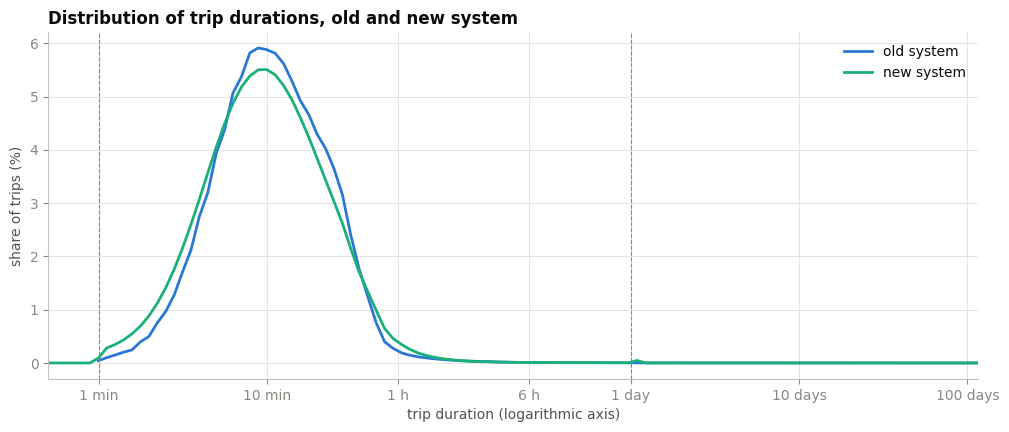

In [27]:
duration_distribution = con.sql(f"""
    WITH t AS (SELECT CASE WHEN source_format = 'new' THEN 'new system' ELSE 'old system' END AS system,
                      {CORRECTED_DURATION} AS duration FROM trips)
    SELECT system, floor(log10(duration) * 20) / 20 AS log_bin, count(*) AS trips
    FROM t WHERE duration >= 1 GROUP BY ALL
""").df()
duration_distribution["share"] = (duration_distribution.trips
                                  / duration_distribution.groupby("system").trips.transform("sum") * 100)

fig, ax = plt.subplots(figsize=(12, 4.5))
for system, colour in [("old system", FORMAT_COLOURS["old"]), ("new system", FORMAT_COLOURS["new"])]:
    part = duration_distribution[duration_distribution.system == system].sort_values("log_bin")
    ax.plot(10 ** (part.log_bin + 0.025), part.share, color=colour, linewidth=2, label=system)
ax.set_xscale("log")
ax.set_xlim(30, 1e7)
ticks = {60: "1 min", 600: "10 min", 3600: "1 h", 6 * 3600: "6 h", 86400: "1 day", 10 * 86400: "10 days",
         100 * 86400: "100 days"}
ax.set_xticks(list(ticks), list(ticks.values()))
ax.minorticks_off()
for seconds in (60, 86400):
    ax.axvline(seconds, color=INK_MUTED, linewidth=0.8, linestyle="--")
ax.set_xlabel("trip duration (logarithmic axis)")
ax.set_ylabel("share of trips (%)")
ax.set_title("Distribution of trip durations, old and new system", loc="left")
ax.legend(loc="upper right", frameon=False)
plt.show()

Both systems have the same shape: a steep start at one minute (the published data begins there, dashed line), a peak around 7 to 10 minutes, and a long tail to the right. The new system has slightly more trips of a few minutes and a slightly heavier tail beyond an hour; whether that is a change in behaviour (e.g. electric bikes) or in who rides is a question for the pattern analysis in `01b`. The tail beyond one day (second dashed line) is invisible at this scale, which confirms that rule D2 removes only a small fraction of the trips.

### 7.2 Stations and coordinates

**Missing stations.** Since 2020 an electric bike can be locked outside a station, so a trip without a start or end station is not automatically an error. We count missing stations and coordinates per bike type.

In [28]:
missing_stations = con.sql("""
    SELECT coalesce(rideable_type, '(old system)') AS bike_type, count(*) AS trips,
           count(*) FILTER (WHERE start_station_id IS NULL) AS no_start_station,
           count(*) FILTER (WHERE end_station_id IS NULL) AS no_end_station,
           count(*) FILTER (WHERE end_station_id IS NULL AND end_lat IS NULL) AS no_end_at_all,
           round(100.0 * count(*) FILTER (WHERE end_station_id IS NULL) / count(*), 2) AS pct_no_end_station
    FROM trips GROUP BY ALL ORDER BY bike_type
""").df()
missing_stations

,bike_type,trips,no_start_station,no_end_station,no_end_at_all,pct_no_end_station
0,(old system),91944402,2677,20736,18059,0.02
1,classic_bike,107718641,1,185662,156103,0.17
2,electric_bike,124154064,86482,471913,433464,0.38


- A missing **start** station is rare (86,482 electric-bike trips, 0.07%; nearly all of them have no start coordinates either, 4.3). A missing **end** station is more common: 0.38% of the electric-bike trips, 0.17% of the classic-bike trips and 0.02% in the old system.
- Most trips without an end station have **no end coordinates either** (84% for classic, 92% for electric bikes): the trip has no known end at all. A closer look at these 607,626 trips (not shown here, to keep the notebook short) found two groups. About a sixth lasts more than 24 hours, with a spike at 24-25 hours: lost bikes whose rental the system closed automatically, already removed by rule D2. Most of the rest last under two hours (median about an hour for electric bikes): rides whose end was not registered, for example a bike that was not docked properly.
- Bike types: only `classic_bike` and `electric_bike` occur; the old system did not record the bike type.

**Rule S1:** trips without a start or end station are kept, because the start of the rental is real and counts for demand. Analyses of end stations, routes or durations skip trips without a known end (no end station and no end coordinates), because their end and duration are unreliable.

**Coordinates.** All stations are in New York City and the nearby part of New Jersey, so all coordinates should fall within a box of about 40.4 to 41.0 degrees north and 73.6 to 74.3 degrees west. The table counts the trips with a coordinate outside that box and groups them by rounded location.

In [29]:
NYC_BOX = "{lat} BETWEEN 40.4 AND 41.0 AND {lng} BETWEEN -74.3 AND -73.6"
outside = con.sql(f"""
    SELECT round(lat, 1) AS lat, round(lng, 1) AS lng, count(*) AS coordinates, any_value(station) AS example_station
    FROM (SELECT start_lat AS lat, start_lng AS lng, start_station_name AS station FROM trips
          UNION ALL
          SELECT end_lat, end_lng, end_station_name FROM trips)
    WHERE lat IS NOT NULL AND NOT ({NYC_BOX.format(lat='lat', lng='lng')})
    GROUP BY ALL ORDER BY coordinates DESC
""").df()
outside

,lat,lng,coordinates,example_station
0,0.0,0.0,415,NYCBS Depot BAL - DYR
1,45.5,-73.6,330,8D QC Station 01
2,34.0,-118.3,79,LA Metro Demo 3
3,34.0,-118.5,2,LA Metro Demo 1
4,41.1,-73.8,1,None


Only a few hundred coordinates lie outside the box, in three groups: `(0, 0)` (a missing position written as zero), Montreal (45.5 N, 73.6 W, test stations of the bike manufacturer, e.g. `8D QC Station 01` and the `MTL-...` stations) and Los Angeles (34.0 N, 118.3 W, `LA Metro Demo` stations). None of them is a real trip in New York. **Rule S2:** coordinates outside the box become NULL; trips at the test stations are removed by rule S3.

**Non-public stations.** The station names also reveal stations that are not used by customers: warehouses (`NYCBS Depot - ...`), workshops (`Shop Morgan`, `GOW Tech Shop`), test and lab stations (`NYCBS Test`, `Lab - NYC`, `Prototype Lab`, `8D ...`, `MTL-...`), demo stations and a portable test kiosk. Trips from or to these stations are moves by staff, not customer trips. Valet stations (e.g. `Penn Station Valet`) are public: staff help customers there, so those trips are real and stay.

In [30]:
NON_PUBLIC = ("'^(NYCBS Depot|NYCBS Test|8D |Kiosk in a box|Mobile 01|GOW Tech Shop|Shop Morgan|Lab - NYC|"
              "Prototype Lab|LA Metro Demo|MTL-)'")
non_public = con.sql(f"""
    SELECT station, count(*) AS trips FROM (
        SELECT start_station_name AS station FROM trips WHERE regexp_matches(start_station_name, {NON_PUBLIC})
        UNION ALL
        SELECT end_station_name FROM trips WHERE regexp_matches(end_station_name, {NON_PUBLIC}))
    GROUP BY ALL ORDER BY trips DESC
""").df()
print(f"{len(non_public)} non-public station names, {non_public.trips.sum():,} trip starts or ends")
non_public.head(15)

34 non-public station names, 25,030 trip starts or ends


,station,trips
0,NYCBS Depot - GOW,5720
1,Shop Morgan,4805
2,NYCBS Depot - SSP,3562
3,Mobile 01,2031
4,NYCBS Depot - FAR,2001
5,NYCBS Depot - STY,1654
6,NYCBS Depot - STY - Garage 4,1367
7,NYCBS Depot - DEL,1012
8,NYCBS Depot - PIT,533
9,Kiosk in a box Motivate,440


**Rule S3:** trips that start or end at a non-public station are removed. These are about 23,000 trips (0.007%), so the effect on counts is negligible, but they would show up as strange outliers on maps and in station rankings.

### 7.3 Round trips

A round trip starts and ends at the same station. That is normal for a leisure ride, but a very short round trip is more likely a bike that was taken out and put back at once (a defect, or the rider changed their mind). The chart shows, per 15 seconds of duration, which share of the trips is a round trip.

 round_trips  pct  median_min  under_3_min
     8422251 2.61     15.7115      1682983


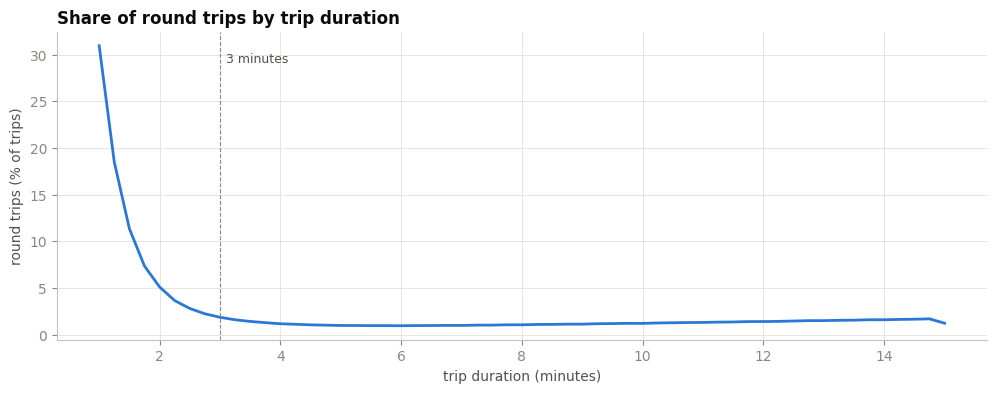

In [31]:
round_trips = con.sql("""
    SELECT floor(duration_s / 15) * 15 AS duration_bin,
           count(*) AS trips, count(*) FILTER (WHERE start_station_id = end_station_id) AS round_trips
    FROM trips
    WHERE duration_s BETWEEN 60 AND 900 AND start_station_id IS NOT NULL AND end_station_id IS NOT NULL
    GROUP BY ALL ORDER BY duration_bin
""").df()
round_trips["share"] = round_trips.round_trips / round_trips.trips * 100
overall = con.sql("""
    SELECT count(*) FILTER (WHERE start_station_id = end_station_id) AS round_trips,
           round(100.0 * count(*) FILTER (WHERE start_station_id = end_station_id) / count(*), 2) AS pct,
           median(duration_s) FILTER (WHERE start_station_id = end_station_id) / 60 AS median_min,
           count(*) FILTER (WHERE start_station_id = end_station_id AND duration_s < 180) AS under_3_min
    FROM trips WHERE start_station_id IS NOT NULL AND end_station_id IS NOT NULL
""").df()
print(overall.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(round_trips.duration_bin / 60, round_trips.share, color=FORMAT_COLOURS["old"], linewidth=2)
ax.axvline(3, color=INK_MUTED, linewidth=0.8, linestyle="--")
ax.text(3.1, ax.get_ylim()[1] * 0.9, "3 minutes", color=INK_SECONDARY, fontsize=9)
ax.set_xlabel("trip duration (minutes)")
ax.set_ylabel("round trips (% of trips)")
ax.set_title("Share of round trips by trip duration", loc="left")
plt.show()

About 2.6% of all trips are round trips, with a median of about 15 minutes: mostly leisure rides. But among trips of one to one and a quarter minutes, 31% are round trips, and the share falls steeply to a stable level of about 1% from four to five minutes on. The extra round trips under about three minutes are therefore not rides but bikes that were docked again straight away. **Rule R1:** round trips shorter than 3 minutes are removed (the chart shows the share has almost reached its baseline there; a stricter 2-minute cut-off would keep part of the excess).

### 7.4 Rider columns: user type, birth year and gender

User type exists in both systems; birth year and gender only in the old one (until 2019).

In [32]:
riders = con.sql("""
    SELECT count(*) AS old_system_trips,
           count(*) FILTER (WHERE user_type IS NULL) AS no_user_type,
           count(*) FILTER (WHERE birth_year IS NULL) AS no_birth_year,
           count(*) FILTER (WHERE birth_year < 1920) AS born_before_1920,
           min(birth_year) AS oldest_birth_year, max(birth_year) AS youngest_birth_year,
           count(*) FILTER (WHERE gender = 0) AS gender_unknown,
           count(*) FILTER (WHERE birth_year = 1969) AS born_1969,
           count(*) FILTER (WHERE birth_year = 1969 AND gender = 0) AS born_1969_gender_unknown
    FROM trips WHERE source_format <> 'new'
""").df()
print(riders.T.to_string(header=False))
empty_user_type = con.sql("""
    SELECT strftime(started_at, '%Y-%m') AS month, count(*) AS trips_without_user_type
    FROM trips WHERE user_type IS NULL GROUP BY ALL ORDER BY month
""").df()
empty_user_type.T

old_system_trips          91944402
no_user_type                 51780
no_birth_year              6229474
born_before_1920             41807
oldest_birth_year             1857
youngest_birth_year           2003
gender_unknown             9385796
born_1969                  4389078
born_1969_gender_unknown   2786911


,0,1,2,3,4,5
month,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03
trips_without_user_type,17949,12534,5388,3193,7580,5136


- **User type:** missing for 51,780 trips, all from October 2016 to March 2017 (the Title Case files). These trips are kept with an unknown user type (**rule U1**); analyses per user type skip them.
- **Gender** is 0 (unknown) for 9.4 million old-system trips (10%), mostly casual riders. It is treated as missing (**rule U2**).
- **Birth year:** besides the 6.2 million missing values (4.3), 41,807 trips have a birth year before 1920, the oldest 1857: riders of over 100 years are not plausible. These become NULL (**rule U3**).

The birth years themselves show one more problem, best seen in a chart:

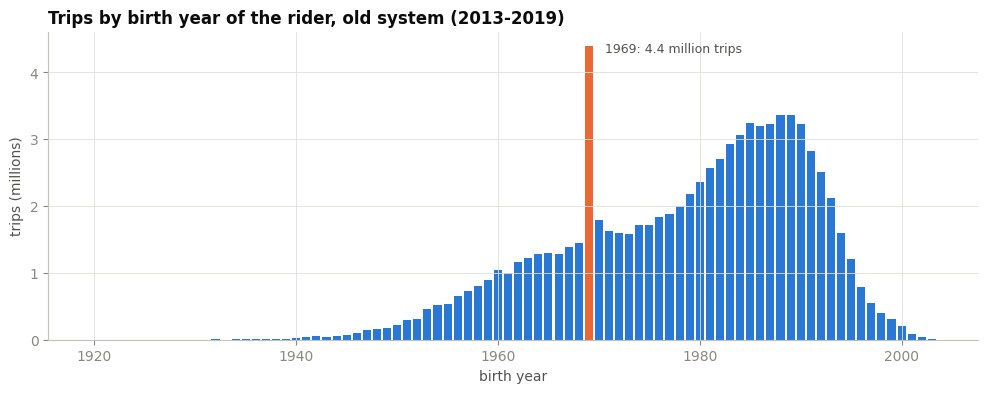

,year,born_1969,born_1969_gender_unknown,born_1968
0,2013,113902,0,96216
1,2014,169242,0,144277
2,2015,195066,40,168955
3,2016,252682,339,220855
4,2017,282502,972,255265
5,2018,1663749,1381443,262314
6,2019,1711935,1404117,293922


In [33]:
birth_years = con.sql("""
    SELECT birth_year, count(*) AS trips FROM trips
    WHERE birth_year BETWEEN 1920 AND 2005 GROUP BY ALL ORDER BY birth_year
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
colours = [FORMAT_COLOURS["old_title_case"] if year == 1969 else FORMAT_COLOURS["old"]
           for year in birth_years.birth_year]
ax.bar(birth_years.birth_year, birth_years.trips / 1e6, width=0.8, color=colours)
peak = birth_years.set_index("birth_year").trips[1969] / 1e6
ax.annotate(f"1969: {peak:.1f} million trips", xy=(1969, peak), xytext=(12, -4), textcoords="offset points",
            fontsize=9, color=INK_SECONDARY)
ax.set_xlabel("birth year")
ax.set_ylabel("trips (millions)")
ax.set_title("Trips by birth year of the rider, old system (2013-2019)", loc="left")
plt.show()

by_year = con.sql("""
    SELECT year(started_at) AS year,
           count(*) FILTER (WHERE birth_year = 1969) AS born_1969,
           count(*) FILTER (WHERE birth_year = 1969 AND gender = 0) AS born_1969_gender_unknown,
           count(*) FILTER (WHERE birth_year = 1968) AS born_1968
    FROM trips WHERE source_format <> 'new' GROUP BY ALL ORDER BY year
""").df()
by_year

Birth year 1969 has 4.4 million trips, three times as many as its neighbours (1.4 million for 1968, 1.8 million for 1970). The table shows where the excess comes from: it starts in 2018, when 1969 suddenly accounts for about 1.7 million trips a year, and most of those riders have gender 0 (unknown). 1969 is evidently the value the system filled in when a (mostly casual) rider gave no birth year. **Rule U3** therefore also sets birth year 1969 to NULL when the gender is unknown; with a known gender we cannot tell a default from a real 1969, so those stay.

### 7.5 Cleaning rules found so far

The rules of this section, with the number of trips each one affects. The rules are not applied to the Parquet files: the data-preparation notebook applies them. "Remove" rules drop a trip; "fix" and "set to NULL" rules keep it.

| Rule | What | Action |
|---|---|---|
| D1 | duration | old system: `tripduration_s`; new system: time-zone-aware difference, +1 hour when still negative |
| D2 | duration over 24 hours (after D1) | remove |
| S1 | no start or end station | keep; skip in end-station, route and duration analyses when the end is unknown |
| S2 | coordinates outside the New York box (incl. `0, 0`) | set to NULL |
| S3 | start or end at a non-public station (depot, workshop, test, lab, demo) | remove |
| R1 | round trip shorter than 3 minutes | remove |
| U1 | empty user type | keep as unknown |
| U2 | gender 0 | set to NULL |
| U3 | birth year before 1920, or 1969 with gender 0 | set to NULL |

The cell below counts the trips per rule (a trip can match more than one rule) and the trips that remain after all "remove" rules.

In [34]:
start = time.time()
impact = con.sql(f"""
    WITH t AS (
        SELECT {CORRECTED_DURATION} AS duration, *,
               regexp_matches(coalesce(start_station_name, ''), {NON_PUBLIC})
                   OR regexp_matches(coalesce(end_station_name, ''), {NON_PUBLIC}) AS non_public
        FROM trips
    )
    SELECT count(*) AS all_trips,
           count(*) FILTER (WHERE abs(duration - duration_s) > 1) AS d1_duration_fixed,
           count(*) FILTER (WHERE duration > 24 * 3600) AS d2_over_24_h,
           count(*) FILTER (WHERE start_station_id IS NULL OR end_station_id IS NULL) AS s1_no_station_kept,
           count(*) FILTER (WHERE NOT ({NYC_BOX.format(lat='start_lat', lng='start_lng')})
                              OR NOT ({NYC_BOX.format(lat='end_lat', lng='end_lng')})) AS s2_coordinates_to_null,
           count(*) FILTER (WHERE non_public) AS s3_non_public,
           count(*) FILTER (WHERE start_station_id = end_station_id AND duration < 180) AS r1_short_round_trip,
           count(*) FILTER (WHERE user_type IS NULL) AS u1_user_type_unknown,
           count(*) FILTER (WHERE gender = 0) AS u2_gender_to_null,
           count(*) FILTER (WHERE birth_year < 1920 OR (birth_year = 1969 AND gender = 0)) AS u3_birth_year_to_null,
           count(*) FILTER (WHERE NOT (duration > 24 * 3600 OR non_public
                                       OR (start_station_id = end_station_id AND duration < 180))) AS trips_kept
    FROM t
""").df().T.rename(columns={0: "trips"})
impact["pct_of_all"] = (impact.trips / impact.trips["all_trips"] * 100).round(3)
print(f"Counted in {time.time() - start:.0f} s")
impact

Counted in 116 s


,trips,pct_of_all
all_trips,323817107,100.000
d1_duration_fixed,1687779,0.521
d2_over_24_h,156916,0.048
s1_no_station_kept,730291,0.226
s2_coordinates_to_null,620,0.000
s3_non_public,23222,0.007
r1_short_round_trip,1683951,0.520
u1_user_type_unknown,51780,0.016
u2_gender_to_null,9385796,2.898
u3_birth_year_to_null,2828718,0.874


The three "remove" rules together drop 0.58% of the trips (1.88 million), mostly short round trips (R1: 1.68 million). The fixes change more rows (D1 corrects about 1.7 million durations, U2 and U3 clear about 12 million rider values), but they keep the trip. The cleaned data will still have about 322 million trips, so the conclusions of the completeness checks (section 6) are not affected by the cleaning.

## 8. A first overview

With the data checked, we take a first look at what it contains: **when** people ride, **who** rides (members and casual riders), **which bikes** they use and **where** the stations are. This is a descriptive overview to orient the deeper analysis; statistical tests and hypotheses follow in `01b` and `01c`.

From here on we use the trips **after the three "remove" rules** of 7.5 (D2, S3, R1) and with the corrected duration (D1). The view `clean_trips` applies them on the fly; it is a preview of what the data-preparation notebook will do. Durations are only averaged over trips with a known end (rule S1).

In [35]:
REMOVE_RULES = f"""
    duration > 24 * 3600
    OR regexp_matches(coalesce(start_station_name, ''), {NON_PUBLIC})
    OR regexp_matches(coalesce(end_station_name, ''), {NON_PUBLIC})
    OR (start_station_id = end_station_id AND duration < 180)
"""
con.execute(f"""
    CREATE OR REPLACE VIEW clean_trips AS
    SELECT * FROM (SELECT *, {CORRECTED_DURATION} AS duration FROM trips) WHERE NOT ({REMOVE_RULES})
""")

start = time.time()
overview = con.sql("""
    SELECT year(started_at) AS year, month(started_at) AS month, dayofweek(started_at) AS weekday,
           hour(started_at) AS hour, user_type, rideable_type,
           count(*) AS trips,
           count(*) FILTER (WHERE end_station_id IS NOT NULL OR end_lat IS NOT NULL) AS trips_with_end,
           sum(duration) FILTER (WHERE end_station_id IS NOT NULL OR end_lat IS NOT NULL) AS duration_sum
    FROM clean_trips GROUP BY ALL
""").df()
print(f"{overview.trips.sum():,} trips in {len(overview):,} groups (built in {time.time() - start:.0f} s)")

321,939,739 trips in 80,964 groups (built in 115 s)


The table `overview` holds the number of trips (and the summed duration) per year, month, weekday, hour, user type and bike type: about 81,000 rows instead of 322 million, enough for every chart in this section. DuckDB numbers the weekdays from 0 (Sunday) to 6 (Saturday).

### 8.1 When do people ride?

The share of the trips that starts in each hour of the day, separately for working days and weekends. We use 2025, the most recent complete year, so the picture shows today's system.

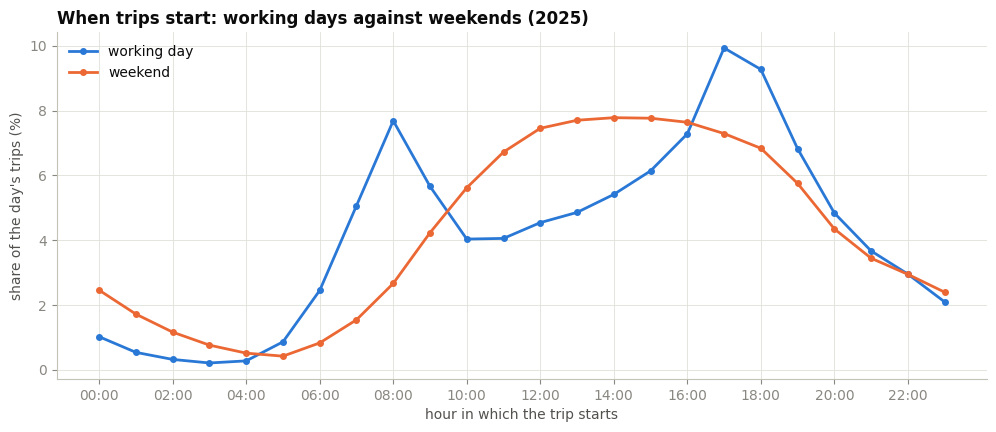

Average trips per day in 2025:
Sunday       107452
Monday       117072
Tuesday      131571
Wednesday    128164
Thursday     130356
Friday       134078
Saturday     125253


In [36]:
WEEKDAY_NAMES = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
year_2025 = overview[overview.year == 2025]
by_hour = (year_2025.assign(day_type=np.where(year_2025.weekday.isin([0, 6]), "weekend", "working day"))
           .groupby(["day_type", "hour"]).trips.sum().unstack(0))
by_hour_share = by_hour / by_hour.sum() * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
for day_type, colour in [("working day", FORMAT_COLOURS["old"]), ("weekend", FORMAT_COLOURS["old_title_case"])]:
    ax.plot(by_hour_share.index, by_hour_share[day_type], color=colour, linewidth=2, marker="o", markersize=4,
            label=day_type)
ax.set_xticks(range(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("hour in which the trip starts")
ax.set_ylabel("share of the day's trips (%)")
ax.set_title("When trips start: working days against weekends (2025)", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()

days_per_weekday = pd.Series(pd.date_range("2025-01-01", "2025-12-31").dayofweek).map(lambda d: (d + 1) % 7).value_counts()
per_weekday = (year_2025.groupby("weekday").trips.sum() / days_per_weekday).rename(index=dict(enumerate(WEEKDAY_NAMES)))
print("Average trips per day in 2025:")
print(per_weekday.round().astype(int).to_string())

Working days and weekends are two different kinds of use:

- **Working days** have two sharp peaks: 08:00-09:00 (7.7% of the day's trips) and 17:00-18:00 (9.9%), the morning and evening rush hours. That is commuting: people ride to and from work or school.
- **Weekends** have no peaks but one broad hump from late morning to early evening (about 7.5% per hour between 12:00 and 17:00), and relatively more trips after midnight: leisure use.
- Per day, Tuesday to Friday are the busiest days (about 128,000 to 134,000 trips on average in 2025) and Sunday the quietest (about 107,000).

The commuter pattern matters for the "going green" theme: a bike trip in the rush hour is the kind of trip that could otherwise have been made by car, taxi or public transport.

### 8.2 Who rides? Members and casual riders

Members have a subscription; casual riders pay per ride or per day. The left chart shows the casual share per year, the right one per month of 2025 (seasons).

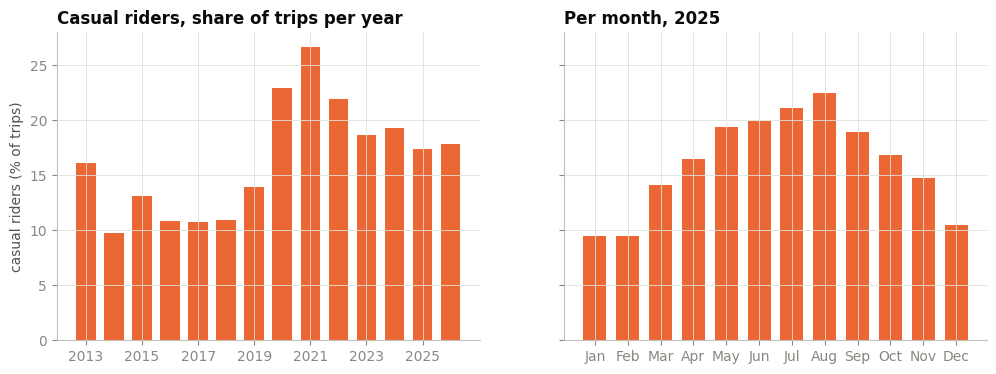

Average trip duration in 2025 (minutes):
user_type
casual    18.7
member    11.1


In [37]:
by_year_user = overview.groupby(["year", "user_type"]).trips.sum().unstack()
casual_share_year = by_year_user.casual / by_year_user.sum(axis=1) * 100
by_month_user = year_2025.groupby(["month", "user_type"]).trips.sum().unstack()
casual_share_month = by_month_user.casual / by_month_user.sum(axis=1) * 100

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
left.bar(casual_share_year.index, casual_share_year.values, color=FORMAT_COLOURS["old_title_case"], width=0.7)
left.set_title("Casual riders, share of trips per year", loc="left")
left.set_ylabel("casual riders (% of trips)")
left.set_xticks(casual_share_year.index[::2])
right.bar(casual_share_month.index, casual_share_month.values, color=FORMAT_COLOURS["old_title_case"], width=0.7)
right.set_title("Per month, 2025", loc="left")
right.set_xticks(range(1, 13), [name[:3] for name in MONTH_NAMES])
plt.show()

with_end = overview[overview.year == 2025].groupby("user_type")[["trips_with_end", "duration_sum"]].sum()
print("Average trip duration in 2025 (minutes):")
print((with_end.duration_sum / with_end.trips_with_end / 60).round(1).to_string())

- Members make most of the trips, but the casual share changed over time: about 10-14% until 2019, a jump to 23% in 2020 and 27% in 2021 (during the pandemic many people tried the bike without a subscription), and back to about 17-19% since 2023.
- Casual riders are **seasonal**: in 2025 they made 9.5% of the trips in January and February against 22.5% in August.
- A casual trip takes much longer than a member trip (18.7 against 11.1 minutes on average in 2025).

Together with 8.1 this suggests two kinds of riders: members who commute (short, frequent, all year) and casual riders who ride for leisure (longer, in summer, at weekends). Whether that holds when tested properly is a question for `01b`, and "member or casual" is one of the candidate prediction targets.

### 8.3 Which bikes? Electric against classic

The bike type is only recorded since 2020. The chart shows the share of trips on an electric bike per month.

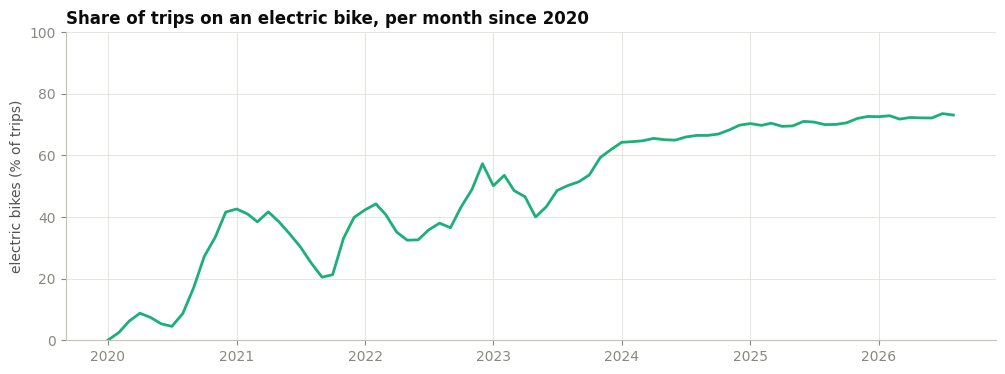

,trips,share_pct,average_minutes
rideable_type,,,
classic_bike,13441977,29.5,12.7
electric_bike,32131320,70.5,12.2


In [38]:
by_month_bike = (overview[overview.year >= 2020].assign(month_start=lambda d: pd.to_datetime(
                     dict(year=d.year, month=d.month, day=1)))
                 .groupby(["month_start", "rideable_type"]).trips.sum().unstack())
electric_share = by_month_bike.electric_bike / by_month_bike.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(electric_share.index, electric_share.values, color=FORMAT_COLOURS["new"], linewidth=2)
ax.set_ylim(0, 100)
ax.set_ylabel("electric bikes (% of trips)")
ax.set_title("Share of trips on an electric bike, per month since 2020", loc="left")
plt.show()

bikes_2025 = overview[overview.year == 2025].groupby("rideable_type")[["trips", "trips_with_end", "duration_sum"]].sum()
bikes_2025["share_pct"] = (bikes_2025.trips / bikes_2025.trips.sum() * 100).round(1)
bikes_2025["average_minutes"] = (bikes_2025.duration_sum / bikes_2025.trips_with_end / 60).round(1)
bikes_2025[["trips", "share_pct", "average_minutes"]]

The share of electric bikes rose from 14% of the trips in 2020 to 70.5% in 2025: electric bikes now carry most of the trips. The rise was not smooth: the share fell back to about 20% in mid-2021 and to about 40% in spring 2023 before climbing steadily to about 73% in 2026. The data does not contain the size of the fleet, so we cannot tell from it whether electric bikes were withdrawn or simply less available in those periods; for analyses that compare the two bike types, those periods need care. Their average trip is about as long as a classic one (in minutes), so electric bikes are probably used to ride **further** in the same time rather than to ride faster over the same distance. Distance is not in the data, but it can be estimated from the start and end coordinates in `01b`. For a "going green" story this is relevant: a longer bike trip replaces a longer car or taxi trip.

### 8.4 Where are the stations?

First the size of the network: the number of distinct start stations per year.

In [39]:
stations_per_year = con.sql("""
    SELECT year(started_at) AS year, count(DISTINCT start_station_id) AS stations
    FROM clean_trips GROUP BY ALL ORDER BY year
""").df()
stations_per_year.set_index("year").T

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
stations,334,332,486,642,799,808,1006,1218,1556,1748,2254,2277,2244,2395


The network grew from 334 stations in 2013 to 2,244 in 2025, almost seven times as many. Part of the growth in trips (6.2) simply follows from more stations in more neighbourhoods. (The count uses station ids, which changed format in 2020; per year this is not a problem because a year uses one format.)

Then a map of all stations used in 2025: every dot is a station at its median start coordinates, and the size of the dot shows the number of trips that started there. No background map is needed; the stations themselves draw the shape of the city.

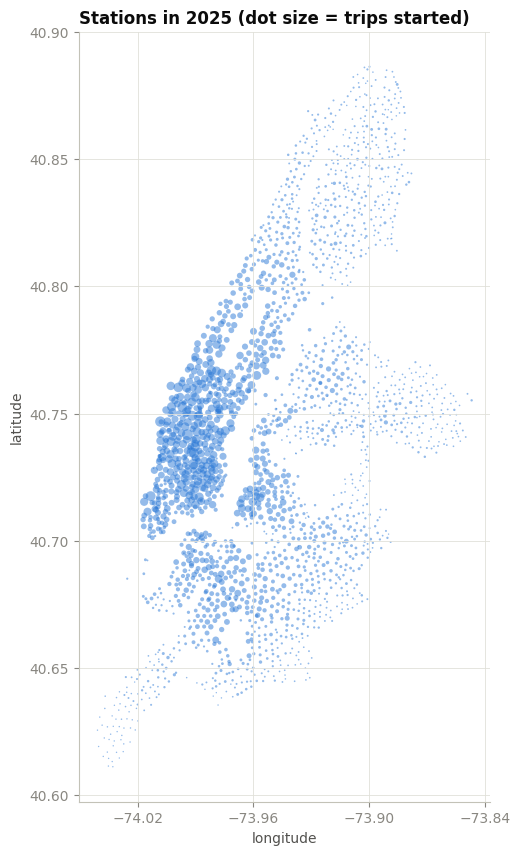

2,244 stations; the busiest 10% account for 38% of the trips


,station,trips
0,W 21 St & 6 Ave,166348
1,Pier 61 at Chelsea Piers,149858
2,Lafayette St & E 8 St,146568
3,West St & Chambers St,139211
4,W 31 St & 7 Ave,138013
5,9 Ave & W 33 St,134524
6,Broadway & E 14 St,133500
7,University Pl & E 14 St,129581
8,11 Ave & W 41 St,129051
9,Broadway & W 58 St,128872


In [40]:
stations_2025 = con.sql(f"""
    SELECT start_station_id, any_value(start_station_name) AS station,
           median(start_lat) AS lat, median(start_lng) AS lng, count(*) AS trips
    FROM clean_trips
    WHERE year(started_at) = 2025 AND start_station_id IS NOT NULL
          AND {NYC_BOX.format(lat='start_lat', lng='start_lng')}
    GROUP BY ALL
""").df()

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(stations_2025.lng, stations_2025.lat, s=stations_2025.trips / stations_2025.trips.max() * 60 + 1,
           color=FORMAT_COLOURS["old"], alpha=0.5, linewidth=0)
ax.set_aspect(1 / np.cos(np.radians(40.75)))  # one degree of longitude is shorter than one of latitude here
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Stations in 2025 (dot size = trips started)", loc="left")
plt.show()

top_share = stations_2025.trips.nlargest(len(stations_2025) // 10).sum() / stations_2025.trips.sum() * 100
print(f"{len(stations_2025):,} stations; the busiest 10% account for {top_share:.0f}% of the trips")
stations_2025.nlargest(10, "trips")[["station", "trips"]].reset_index(drop=True)

The map shows Manhattan (the long dense band) with the biggest dots, and the network spreading into Brooklyn (south-east), Queens (east) and the Bronx (north-east) with smaller dots. Use is very uneven: the busiest 10% of the stations account for 38% of the trips. The busiest stations are in Manhattan around Chelsea and Midtown (e.g. W 21 St & 6 Ave and Pier 61 at Chelsea Piers) and near the transit hubs, which fits the commuter pattern of 8.1.

**What the overview gives the next notebooks:** a commuting and a leisure pattern (8.1, 8.2), the rise of the electric bike (8.3) and a network that grew and is used very unevenly (8.4). These are the starting points for `01b` (patterns with statistical evidence, weather) and `01c` (hypothesis).

## 9. Decisions for the data-preparation notebook

This notebook changed the data only where it had to (one schema, every trip once). All other cleaning is left to the data-preparation notebook, which must take the following decisions over. The table collects them, with the section where the evidence is.

| # | Decision | Why | Section |
|---|---|---|---|
| 1 | Read only the CSVs directly in the month folders, never `Origineel/` | the unsplit copies hold the same trips (19 of 19 months equal) | 2, 4.2 |
| 2 | Use the Parquet layer `Data/parquet/trips/` (one schema, 323,817,107 trips) as input | 6x smaller, typed, every CSV line accounted for | 3, 4.1 |
| 3 | Station ids of the new system with two decimals (`5024.1` -> `5024.10`) | same station written two ways | 3.2 |
| 4 | Every trip once (531 duplicate copies removed) | month-boundary copies and double logs | 3.4, 4.4 |
| 5 | Count and split trips by `started_at`, never by `source_month` | the new system files trips by end month | 6.1 |
| 6 | Keep the 10 days without trips | real closures (storms), not missing data | 6.4 |
| 7 | D1: corrected duration (old: `tripduration_s`; new: time-zone-aware, +1 h if negative) | daylight saving, 2015 without seconds | 7.1 |
| 8 | D2: remove trips over 24 hours | lost or stolen bikes, not rides | 7.1 |
| 9 | S1: keep trips without a station; skip trips without a known end in end-station, route and duration analyses | the start is real, the end and duration are not | 7.2 |
| 10 | S2: coordinates outside the New York box to NULL | `0, 0`, test stations in Montreal and Los Angeles | 7.2 |
| 11 | S3: remove trips from or to non-public stations | staff moves, not customer trips | 7.2 |
| 12 | R1: remove round trips under 3 minutes | re-docks, not rides | 7.3 |
| 13 | U1: empty user type stays unknown | 51,780 trips, no way to recover it | 7.4 |
| 14 | U2: gender 0 to NULL | 0 means unknown | 7.4 |
| 15 | U3: birth year before 1920, or 1969 with gender 0, to NULL | implausible ages and the system's default value | 7.4 |

**Paths not taken** (and why):

- **Reading the CSVs with pandas in chunks** instead of DuckDB: possible, but much slower and more code for every question; DuckDB answers most questions in seconds from the Parquet files.
- **Comparing a fingerprint of all columns** to find duplicates (3.4): slower (7 minutes) and it missed a duplicate whose station had been renamed; the key (`ride_id`, or bike + start time) is stricter.
- **Removing trips without a station**: would remove real rentals (mostly electric bikes) and bias the counts against electric bikes; they are kept and skipped only where the end matters.
- **A 2-minute cut-off for short round trips** instead of 3 minutes: the share of round trips is still clearly above its baseline between 2 and 3 minutes (7.3).
- **Removing the storm days**: they are real; a demand model should learn them from weather, not have them hidden.
- **Filling in missing birth years or genders** (imputation): they are missing mostly for casual riders, so any filled-in value would be a guess about exactly the group we want to compare; they stay missing.
- **Converting all timestamps to UTC in the Parquet files**: the local time is what matters for behaviour (rush hours), and the time-zone conversion is only needed for durations, so it is done in rule D1 instead.

## 10. Summary

- **Input:** the 400 CSVs directly inside the month folders (60.9 GB, June 2013 to August 2026, no month missing). The 19 unsplit copies in `Origineel/` are skipped; 4.2 proves they hold exactly the same trips.
- **Output:** one harmonised table of **323,817,107 trips** in 159 Parquet files (`Data/parquet/trips/`, about 10 GB instead of 61 GB), with one schema for the three CSV formats (3.1).
- **Fixes during the conversion:** fixed CSV dialect (quoted station names), four timestamp shapes, old station ids written as decimals, new station ids written with one decimal (3.2).
- **Duplicates:** 531 trips stored twice (512 at the April/May 2026 boundary, 19 in the old system) are stored once now; the removed copies are kept in `Data/parquet/removed_duplicates.parquet`.
- **Verified:** every CSV line is accounted for (4.1), no unreadable timestamps (4.3), no duplicate keys left (4.4).
- **Complete over time (6):** every month and every day from June 2013 to August 2026 has trips, except 10 winter days without any trip (storms, kept as real events). The old system files trips by start month, the new system by end month (except April 2026), so all counts use `started_at`.
- **Data quality per column (7):** nine rules (7.5). Durations: the old system's reported duration and a time-zone-aware duration for the new system replace the plain difference (daylight saving); trips over 24 hours, trips at non-public stations and round trips under 3 minutes are removed (together less than 1% of the trips); impossible coordinates, gender 0 and implausible or default birth years (before 1920, 1969 with unknown gender) become NULL.
- **First overview (8):** commuting peaks on working days and leisure at weekends; casual riders are seasonal and ride longer; electric bikes went from 14% to about 70% of the trips since 2020; the network grew from 334 to about 2,250 stations and is used very unevenly.
- **Decisions (9):** 15 decisions and the paths not taken, as input for the data-preparation notebook.

Next: `01b_eda_patterns.ipynb` (patterns with statistical evidence and weather data) and `01c_eda_hypothesis.ipynb` (a testable hypothesis), both reading the Parquet layer and applying the decisions of section 9 the way `clean_trips` does here.